**1. Import Libraries**

In [1]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [3]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)


In [4]:
# Display settings
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


**2. Upload and Load the Dataset**

In [5]:

from google.colab import files

uploaded = files.upload()

Saving cardio_train.csv to cardio_train.csv


In [6]:
# LOAD THE DATASET

df = pd.read_csv("cardio_train.csv", sep=";")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


**3. Initial Data Inspection**

In [8]:

# Dataset shape
print("Dataset Shape:")
print(df.shape)

print("\n" + "=" * 50)


Dataset Shape:
(70000, 13)



In [9]:
# Column names
print("Column Names:")
print(df.columns.tolist())

print("\n" + "=" * 50)


Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']



In [10]:
# Dataset information
print("Dataset Information:")
df.info()

print("\n" + "=" * 50)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB



In [11]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "=" * 50)


Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64



In [12]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "=" * 50)


Duplicate Rows: 0



In [13]:
# Statistical summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


**4. Data Cleaning and Preprocessing**

In [14]:
# CREATE DATASET COPY

df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)

Original dataset shape: (70000, 13)


In [15]:
# REMOVE ID COLUMN

df_clean.drop("id", axis=1, inplace=True)

print("ID column removed successfully!")
print("New dataset shape:", df_clean.shape)

ID column removed successfully!
New dataset shape: (70000, 12)


In [16]:
# CONVERT AGE TO YEARS
df_clean["age_years"] = df_clean["age"] / 365.25

# Round age to 1 decimal place
df_clean["age_years"] = df_clean["age_years"].round(1)

# Remove original age column
df_clean.drop("age", axis=1, inplace=True)

df_clean.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4
2,1,165,64.0,130,70,3,1,0,0,0,1,51.6
3,2,169,82.0,150,100,1,1,0,0,1,1,48.2
4,1,156,56.0,100,60,1,1,0,0,0,0,47.8


In [17]:
#CHECK AGE RANGE

print("Minimum age:", df_clean["age_years"].min())
print("Maximum age:", df_clean["age_years"].max())

Minimum age: 29.6
Maximum age: 64.9


In [18]:
# CHECK MISSING VALUES

missing_values = df_clean.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

Total missing values: 0


In [19]:
# CHECK DUPLICATES

duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 674


In [20]:
df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (69326, 12)


In [21]:
# CHECK HEIGHT

print(df_clean["height"].describe())

count    69326.000000
mean       164.357283
std          8.237735
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64


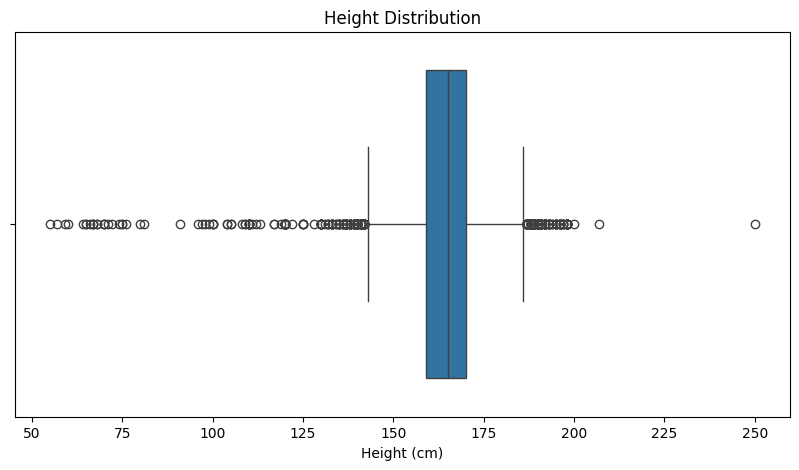

In [22]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df_clean["height"])

plt.title("Height Distribution")
plt.xlabel("Height (cm)")

plt.show()

In [23]:
#CHECK WEIGHT

print(df_clean["weight"].describe())

count    69326.000000
mean        74.279423
std         14.432048
min         10.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64


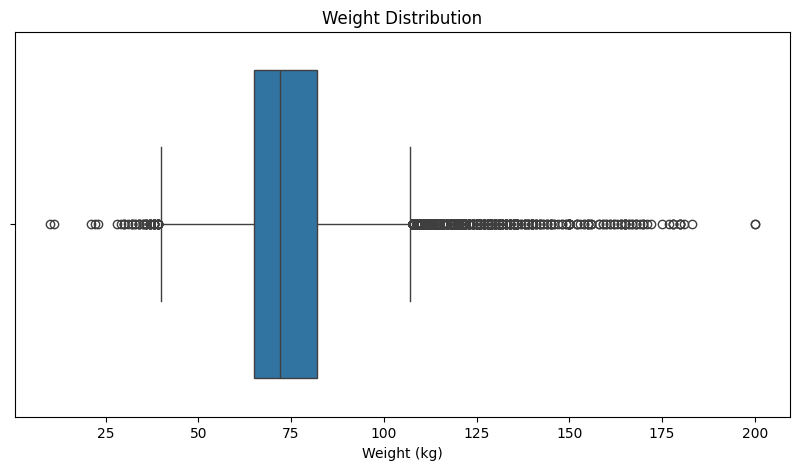

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df_clean["weight"])

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")

plt.show()

In [25]:
#height and weight filtering
df_clean = df_clean[
    (df_clean["height"] >= 120) &
    (df_clean["height"] <= 220) &
    (df_clean["weight"] >= 30) &
    (df_clean["weight"] <= 200)
]

print("Dataset shape after height and weight filtering:")
print(df_clean.shape)

Dataset shape after height and weight filtering:
(69266, 12)


In [26]:
#CHECK BLOOD PRESSURE

print("Systolic Blood Pressure:")
print(df_clean["ap_hi"].describe())

print("\nDiastolic Blood Pressure:")
print(df_clean["ap_lo"].describe())

Systolic Blood Pressure:
count    69266.000000
mean       128.906693
std        154.819919
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

Diastolic Blood Pressure:
count    69266.000000
mean        96.794445
std        189.421429
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64


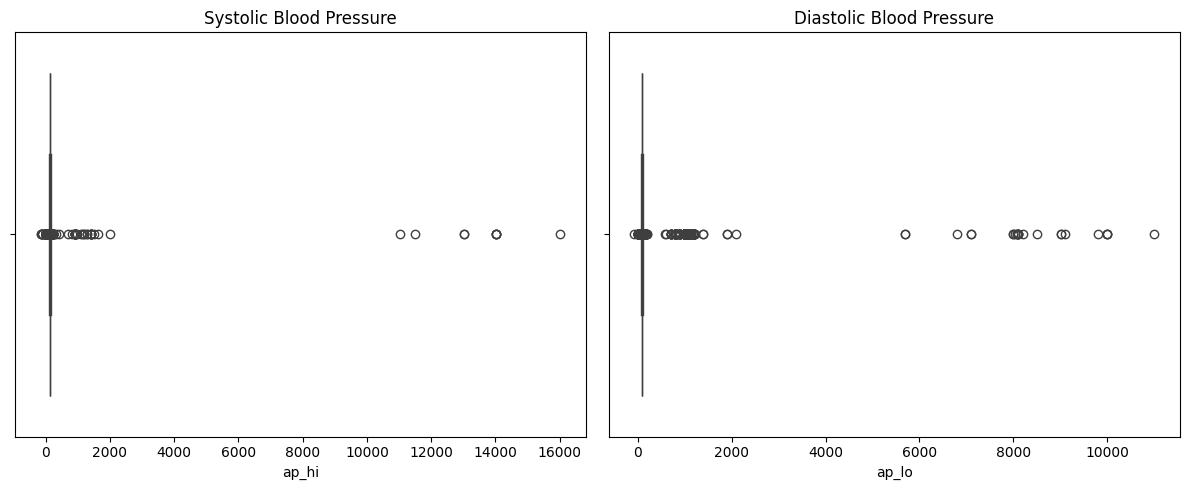

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_clean["ap_hi"])
plt.title("Systolic Blood Pressure")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean["ap_lo"])
plt.title("Diastolic Blood Pressure")

plt.tight_layout()
plt.show()

In [28]:
#blood pressure filtering
df_clean = df_clean[
    (df_clean["ap_hi"] >= 80) &
    (df_clean["ap_hi"] <= 250) &
    (df_clean["ap_lo"] >= 40) &
    (df_clean["ap_lo"] <= 150)
]

print("Dataset shape after blood pressure filtering:")
print(df_clean.shape)

Dataset shape after blood pressure filtering:
(68008, 12)


In [29]:
# CHECK BLOOD PRESSURE RELATIONSHIP

invalid_bp = (df_clean["ap_hi"] <= df_clean["ap_lo"]).sum()

print("Records where systolic <= diastolic:", invalid_bp)

Records where systolic <= diastolic: 76


In [30]:
df_clean = df_clean[
    df_clean["ap_hi"] > df_clean["ap_lo"]
]

print("Dataset shape after BP relationship check:")
print(df_clean.shape)

Dataset shape after BP relationship check:
(67932, 12)


In [31]:
# CHECK CATEGORICAL VARIABLES

categorical_columns = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df_clean[column].value_counts().sort_index())


gender:
gender
1    44128
2    23804
Name: count, dtype: int64

cholesterol:
cholesterol
1    50784
2     9292
3     7856
Name: count, dtype: int64

gluc:
gluc
1    57661
2     5064
3     5207
Name: count, dtype: int64

smoke:
smoke
0    61899
1     6033
Name: count, dtype: int64

alco:
alco
0    64272
1     3660
Name: count, dtype: int64

active:
active
0    13444
1    54488
Name: count, dtype: int64

cardio:
cardio
0    34149
1    33783
Name: count, dtype: int64


In [32]:
# CHECK VALID CATEGORICAL VALUES

print("Gender values:", sorted(df_clean["gender"].unique()))
print("Cholesterol values:", sorted(df_clean["cholesterol"].unique()))
print("Glucose values:", sorted(df_clean["gluc"].unique()))
print("Smoking values:", sorted(df_clean["smoke"].unique()))
print("Alcohol values:", sorted(df_clean["alco"].unique()))
print("Activity values:", sorted(df_clean["active"].unique()))
print("Target values:", sorted(df_clean["cardio"].unique()))

Gender values: [np.int64(1), np.int64(2)]
Cholesterol values: [np.int64(1), np.int64(2), np.int64(3)]
Glucose values: [np.int64(1), np.int64(2), np.int64(3)]
Smoking values: [np.int64(0), np.int64(1)]
Alcohol values: [np.int64(0), np.int64(1)]
Activity values: [np.int64(0), np.int64(1)]
Target values: [np.int64(0), np.int64(1)]


In [33]:
# FINAL CLEANING CHECK

print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nDataset information:")
df_clean.info()

Final dataset shape: (67932, 12)

Missing values:
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

Duplicate rows:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 67932 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gender       67932 non-null  int64  
 1   height       67932 non-null  int64  
 2   weight       67932 non-null  float64
 3   ap_hi        67932 non-null  int64  
 4   ap_lo        67932 non-null  int64  
 5   cholesterol  67932 non-null  int64  
 6   gluc         67932 non-null  int64  
 7   smoke        67932 non-null  int64  
 8   alco         67932 non-null  int64  
 9   active       67932 non-null  int64  
 10  cardio       67932 non-null  int64  
 11  age_years    67932 non-null  float64


In [34]:
display(df_clean.head(10))

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4
2,1,165,64.0,130,70,3,1,0,0,0,1,51.6
3,2,169,82.0,150,100,1,1,0,0,1,1,48.2
4,1,156,56.0,100,60,1,1,0,0,0,0,47.8
5,1,151,67.0,120,80,2,2,0,0,0,0,60.0
6,1,157,93.0,130,80,3,1,0,0,1,0,60.5
7,2,178,95.0,130,90,3,3,0,0,1,1,61.8
8,1,158,71.0,110,70,1,1,0,0,1,0,48.4
9,1,164,68.0,110,60,1,1,0,0,0,0,54.3


In [35]:
display(df_clean.describe())

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000,67932.000000
mean,1.350409,164.412147,74.190277,126.738135,81.319128,1.368074,1.227845,0.088809,0.053877,0.802096,0.497306,53.294268
std,0.477102,7.939136,14.332595,16.737393,9.457879,0.681097,0.573792,0.284471,0.225777,0.398422,0.499996,6.765940
min,1.000000,120.000000,30.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.600000
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.300000
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.900000
75%,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.400000
max,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.900000


**5. Feature Engineering**

In [36]:
#Calculate BMI
# CREATE BMI FEATURE


df_clean["bmi"] = df_clean["weight"] / (
    (df_clean["height"] / 100) ** 2
)

# Round BMI to 2 decimal places
df_clean["bmi"] = df_clean["bmi"].round(2)

df_clean[["height", "weight", "bmi"]].head(10)

,height,weight,bmi
0,168,62.0,21.97
1,156,85.0,34.93
2,165,64.0,23.51
3,169,82.0,28.71
4,156,56.0,23.01
5,151,67.0,29.38
6,157,93.0,37.73
7,178,95.0,29.98
8,158,71.0,28.44
9,164,68.0,25.28


In [37]:
print("BMI Statistics:")
print(df_clean["bmi"].describe())

BMI Statistics:
count    67932.000000
mean        27.486171
std          5.270726
min         10.730000
25%         23.880000
50%         26.400000
75%         30.180000
max        108.170000
Name: bmi, dtype: float64


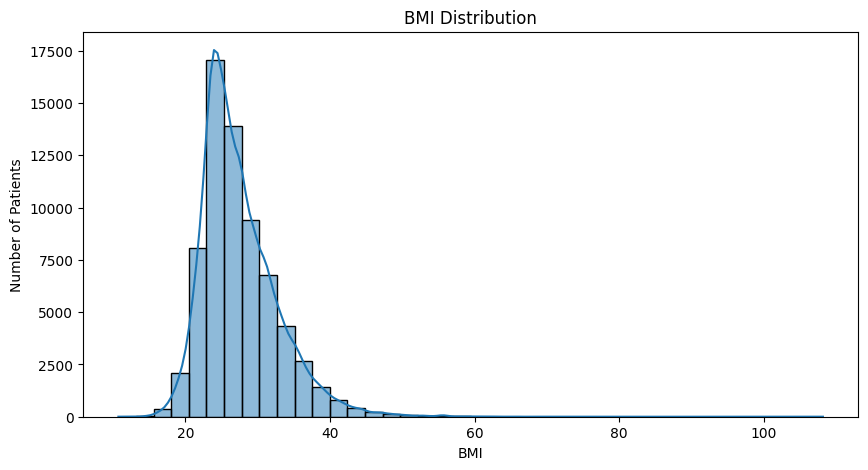

In [38]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["bmi"],
    bins=40,
    kde=True
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

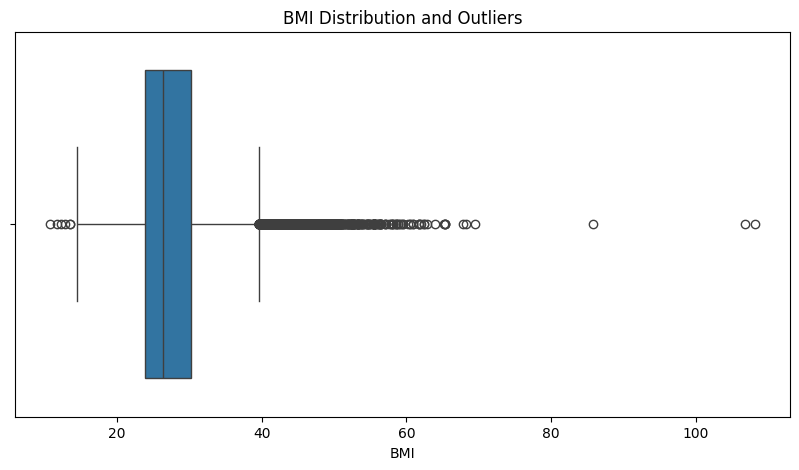

In [40]:
# Check BMI Outliers
plt.figure(figsize=(10, 5))

sns.boxplot(x=df_clean["bmi"])

plt.title("BMI Distribution and Outliers")
plt.xlabel("BMI")

plt.show()

In [42]:
df_clean = df_clean[
    (df_clean["bmi"] >= 12) &
    (df_clean["bmi"] <= 60)
]

print("Dataset shape after BMI filtering:")
print(df_clean.shape)

Dataset shape after BMI filtering:
(67907, 13)


In [43]:
# BLOOD PRESSURE DIFFERENCE

df_clean["bp_difference"] = (
    df_clean["ap_hi"] - df_clean["ap_lo"]
)

df_clean[[
    "ap_hi",
    "ap_lo",
    "bp_difference"
]].head(10)

,ap_hi,ap_lo,bp_difference
0,110,80,30
1,140,90,50
2,130,70,60
3,150,100,50
4,100,60,40
5,120,80,40
6,130,80,50
7,130,90,40
8,110,70,40
9,110,60,50


In [44]:
print(df_clean["bp_difference"].describe())

count    67907.000000
mean        45.416732
std         11.704505
min          5.000000
25%         40.000000
50%         40.000000
75%         50.000000
max        140.000000
Name: bp_difference, dtype: float64


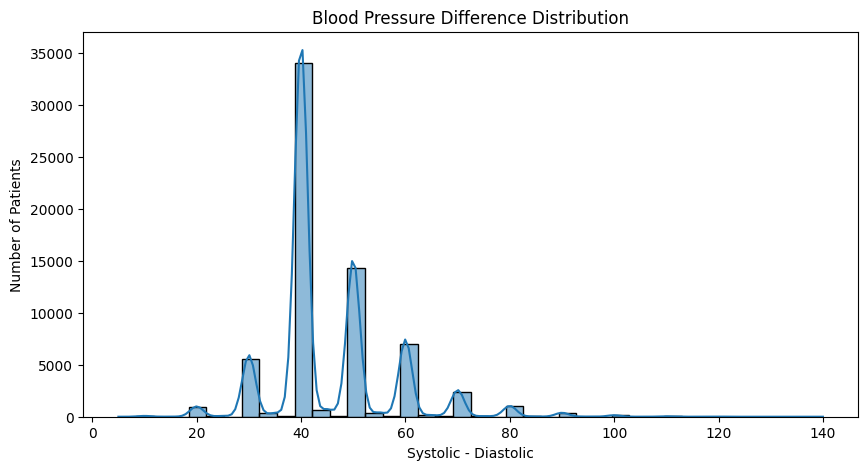

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["bp_difference"],
    bins=40,
    kde=True
)

plt.title("Blood Pressure Difference Distribution")
plt.xlabel("Systolic - Diastolic")
plt.ylabel("Number of Patients")

plt.show()

In [46]:
# BLOOD PRESSURE RATIO

df_clean["bp_ratio"] = (
    df_clean["ap_hi"] / df_clean["ap_lo"]
)

df_clean["bp_ratio"] = df_clean["bp_ratio"].round(2)

df_clean[[
    "ap_hi",
    "ap_lo",
    "bp_difference",
    "bp_ratio"
]].head(10)

,ap_hi,ap_lo,bp_difference,bp_ratio
0,110,80,30,1.38
1,140,90,50,1.56
2,130,70,60,1.86
3,150,100,50,1.50
4,100,60,40,1.67
5,120,80,40,1.50
6,130,80,50,1.62
7,130,90,40,1.44
8,110,70,40,1.57
9,110,60,50,1.83


In [47]:
print(df_clean["bp_ratio"].describe())

count    67907.000000
mean         1.562641
std          0.149765
min          1.060000
25%          1.500000
50%          1.500000
75%          1.620000
max          4.000000
Name: bp_ratio, dtype: float64


In [48]:
# CREATE AGE GROUP

def age_group(age):
    if age < 40:
        return "Young Adult"
    elif age < 55:
        return "Middle Age"
    else:
        return "Senior"

df_clean["age_group"] = df_clean["age_years"].apply(age_group)

df_clean["age_group"].value_counts()

,count
age_group,
Middle Age,35931
Senior,30306
Young Adult,1670


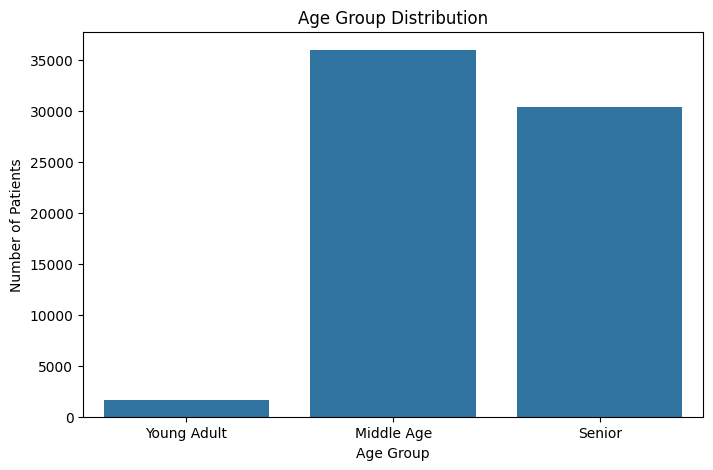

In [49]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="age_group",
    order=["Young Adult", "Middle Age", "Senior"]
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()

In [50]:
# CREATE BMI CATEGORY

def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["bmi_category"] = df_clean["bmi"].apply(bmi_category)

df_clean["bmi_category"].value_counts()

,count
bmi_category,
Normal,24806
Overweight,24537
Obese,17937
Underweight,627


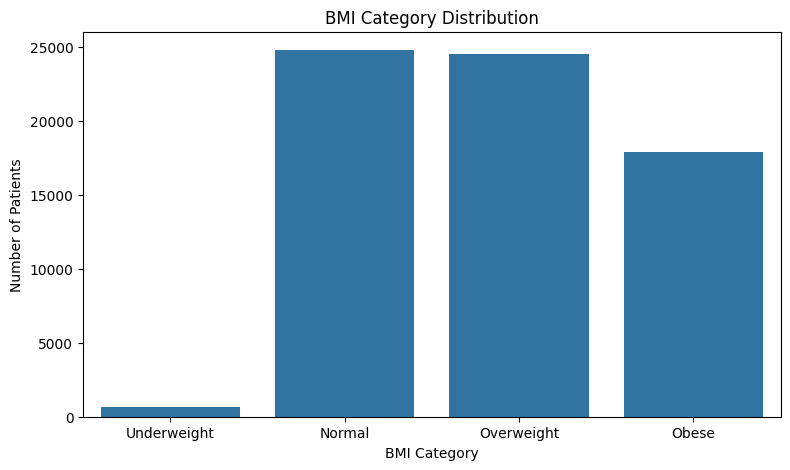

In [51]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="bmi_category",
    order=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Number of Patients")

plt.show()

In [52]:
# Compare BMI Category With Cardiovascular Disease

bmi_cardio = pd.crosstab(
    df_clean["bmi_category"],
    df_clean["cardio"],
    normalize="index"
) * 100

bmi_cardio

cardio,0,1
bmi_category,,
Normal,59.925018,40.074982
Obese,37.481184,62.518816
Overweight,49.288829,50.711171
Underweight,72.727273,27.272727


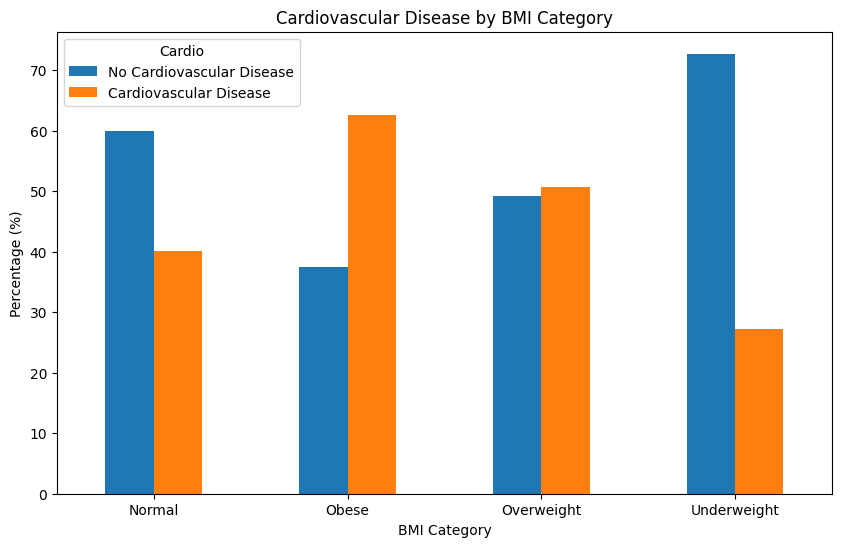

In [53]:
bmi_cardio.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cardiovascular Disease by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)
plt.legend(
    ["No Cardiovascular Disease", "Cardiovascular Disease"],
    title="Cardio"
)

plt.show()

In [54]:
# Compare Age Group With Cardiovascular Disease

age_cardio = pd.crosstab(
    df_clean["age_group"],
    df_clean["cardio"],
    normalize="index"
) * 100

age_cardio


cardio,0,1
age_group,,
Middle Age,58.359077,41.640923
Senior,39.285950,60.714050
Young Adult,75.628743,24.371257


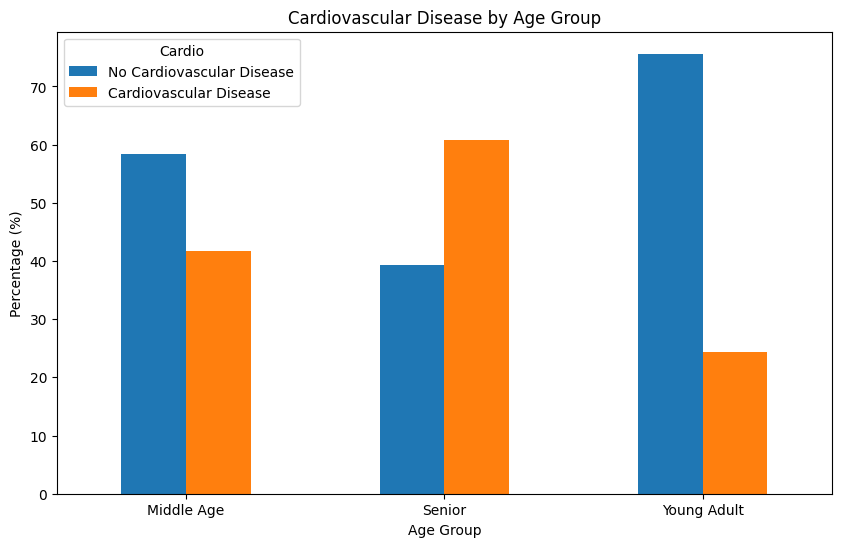

In [55]:
age_cardio.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cardiovascular Disease by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)
plt.legend(
    ["No Cardiovascular Disease", "Cardiovascular Disease"],
    title="Cardio"
)

plt.show()

In [56]:
# Review All Features

print("All features:")
print(df_clean.columns.tolist())

All features:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_difference', 'bp_ratio', 'age_group', 'bmi_category']


In [57]:
display(df_clean.head(10))

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_difference,bp_ratio,age_group,bmi_category
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.97,30,1.38,Middle Age,Normal
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.93,50,1.56,Senior,Obese
2,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.51,60,1.86,Middle Age,Normal
3,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.71,50,1.50,Middle Age,Overweight
4,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.01,40,1.67,Middle Age,Normal
5,1,151,67.0,120,80,2,2,0,0,0,0,60.0,29.38,40,1.50,Senior,Overweight
6,1,157,93.0,130,80,3,1,0,0,1,0,60.5,37.73,50,1.62,Senior,Obese
7,2,178,95.0,130,90,3,3,0,0,1,1,61.8,29.98,40,1.44,Senior,Overweight
8,1,158,71.0,110,70,1,1,0,0,1,0,48.4,28.44,40,1.57,Middle Age,Overweight
9,1,164,68.0,110,60,1,1,0,0,0,0,54.3,25.28,50,1.83,Middle Age,Overweight


In [58]:
# Final dataset

print("Final shape after feature engineering:")
print(df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Final shape after feature engineering:
(67907, 17)

Missing values:
gender           0
height           0
weight           0
ap_hi            0
ap_lo            0
cholesterol      0
gluc             0
smoke            0
alco             0
active           0
cardio           0
age_years        0
bmi              0
bp_difference    0
bp_ratio         0
age_group        0
bmi_category     0
dtype: int64

Duplicate rows:
0


**6. Exploratory Data Analysis (EDA)**

In [59]:
# TARGET DISTRIBUTION

print("Cardiovascular Disease Distribution:")
print(df_clean["cardio"].value_counts())

print("\nPercentage Distribution:")
print(
    df_clean["cardio"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Cardiovascular Disease Distribution:
cardio
0    34138
1    33769
Name: count, dtype: int64

Percentage Distribution:
cardio
0    50.27
1    49.73
Name: proportion, dtype: float64


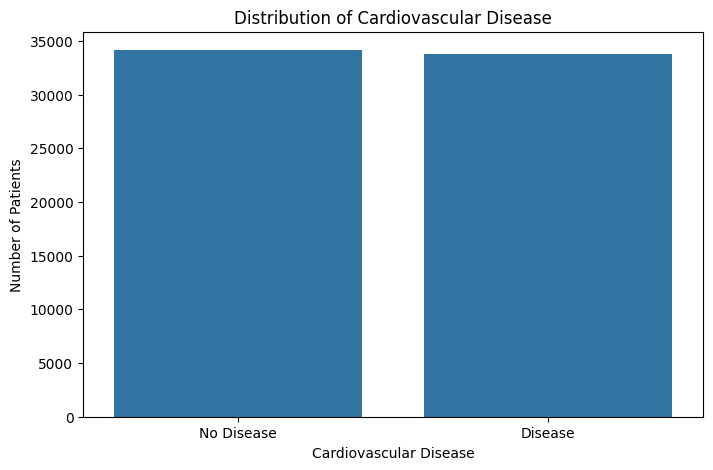

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="cardio"
)

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

In [61]:
# ==========================================
# GENDER VS CARDIO


gender_cardio = pd.crosstab(
    df_clean["gender"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(gender_cardio.round(2))

cardio      0      1
gender              
1       50.47  49.53
2       49.90  50.10


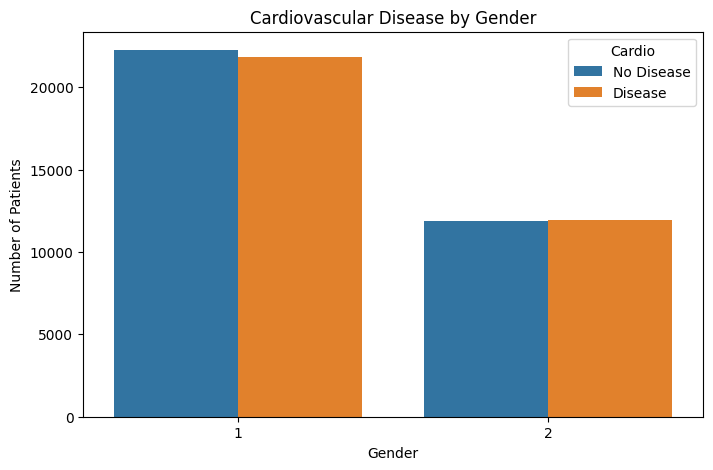

In [62]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="gender",
    hue="cardio"
)

plt.title("Cardiovascular Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.show()

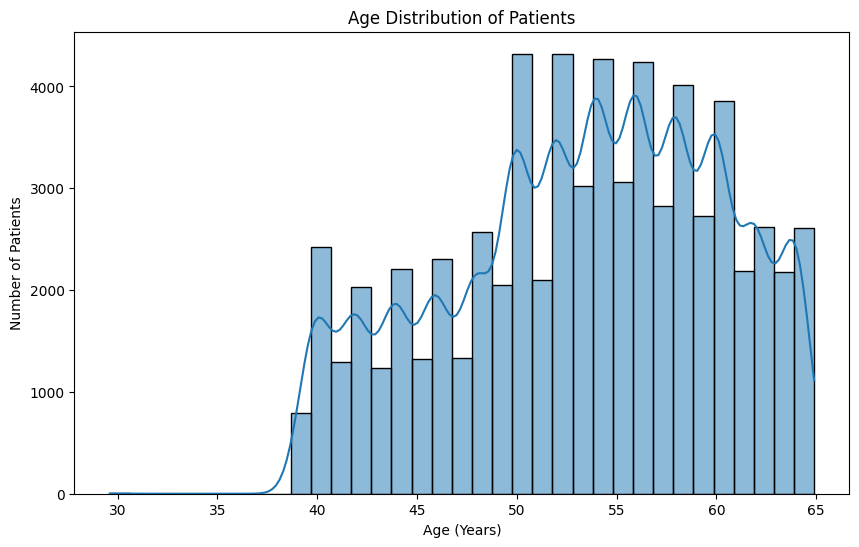

In [63]:
# ==========================================
# AGE DISTRIBUTION


plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="age_years",
    bins=35,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.show()

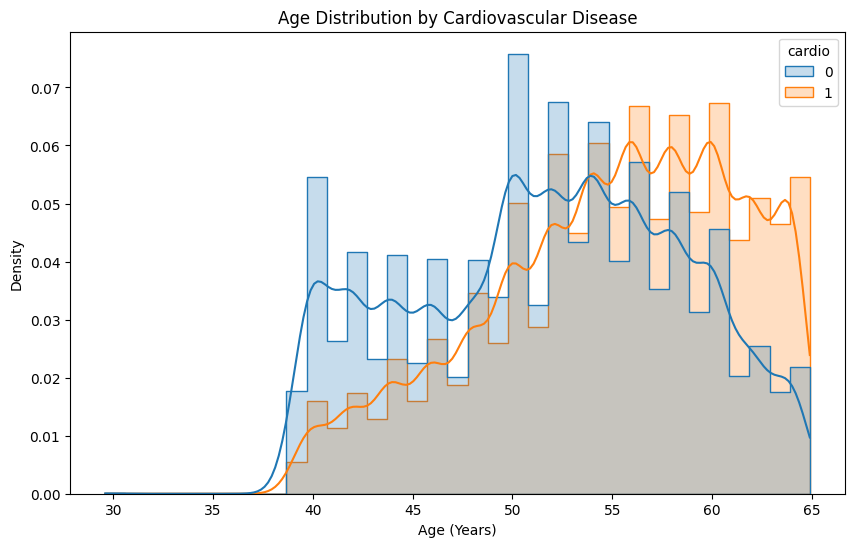

In [64]:
# compare age between the two target classes

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="age_years",
    hue="cardio",
    bins=35,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Age (Years)")
plt.ylabel("Density")

plt.show()

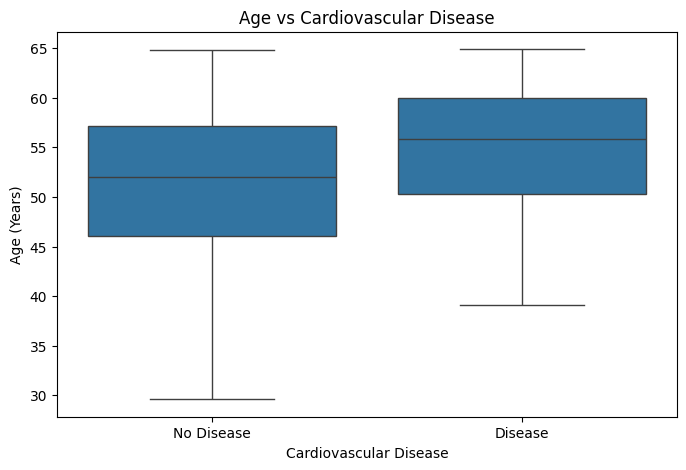

In [65]:
# Age vs Cardiovascular Disease

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="age_years"
)

plt.title("Age vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Age (Years)")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

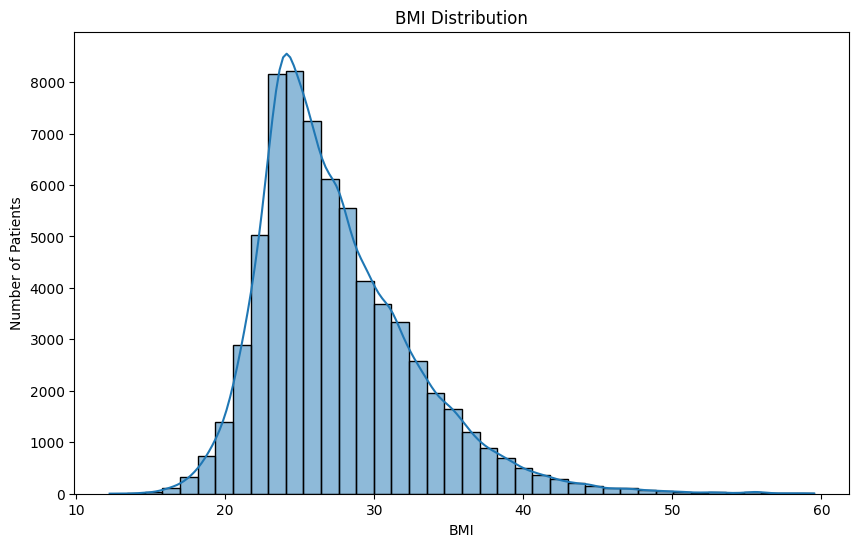

In [66]:
# ==========================================
# BMI ANALYSIS
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="bmi",
    bins=40,
    kde=True
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

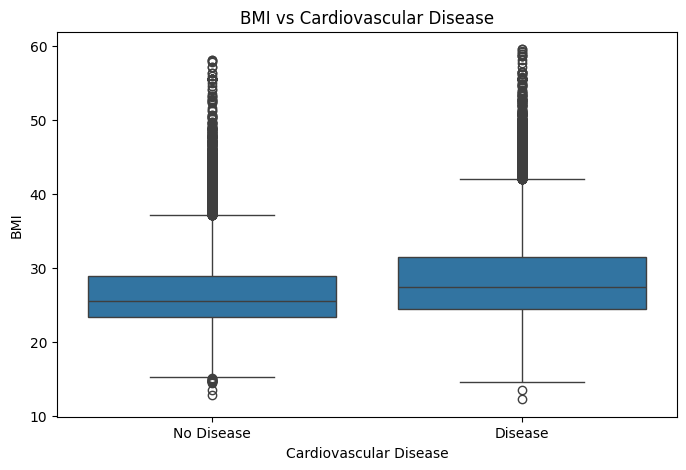

In [67]:
#compare BMI by cardiovascular disease

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="bmi"
)

plt.title("BMI vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("BMI")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

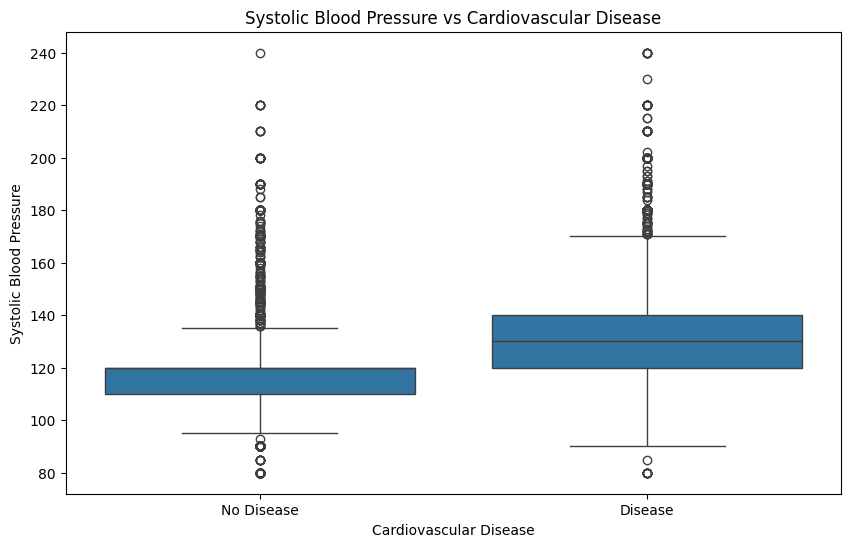

In [69]:
# ==========================================
# BLOOD PRESSURE ANALYSIS
# ==========================================

# Systolic Blood Pressure

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="ap_hi"
)

plt.title("Systolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Systolic Blood Pressure")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

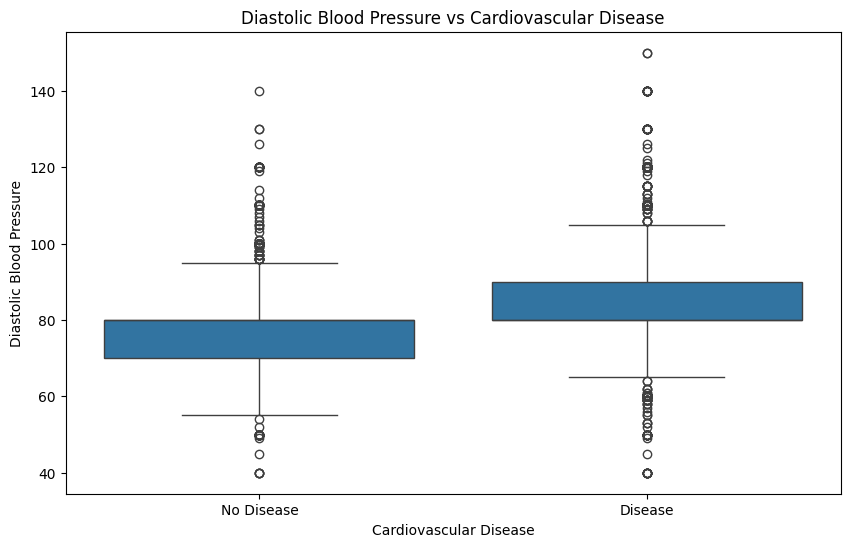

In [70]:
# Diastolic Blood Pressure

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="ap_lo"
)

plt.title("Diastolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Diastolic Blood Pressure")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

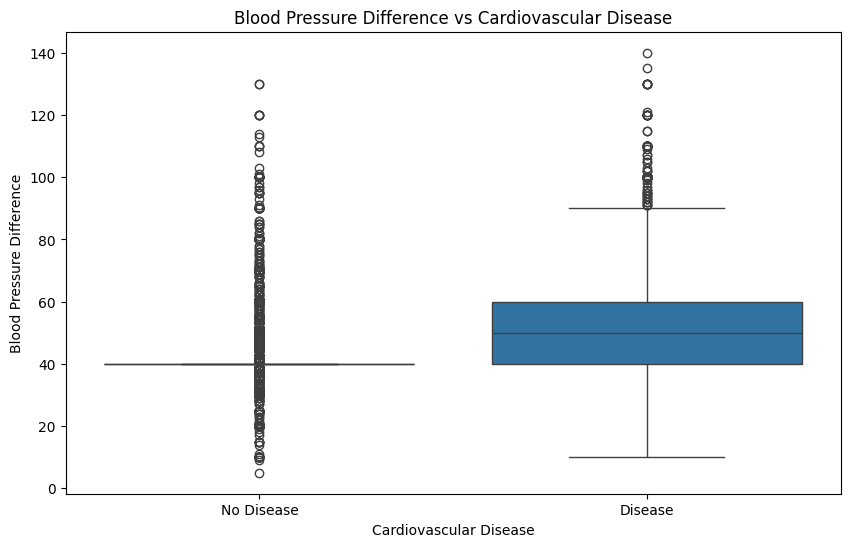

In [71]:
# Blood Pressure Difference

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="cardio",
    y="bp_difference"
)

plt.title("Blood Pressure Difference vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Blood Pressure Difference")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

In [72]:
# ==========================================
# CHOLESTEROL ANALYSIS
# ==========================================

cholesterol_cardio = pd.crosstab(
    df_clean["cholesterol"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(cholesterol_cardio.round(2))

cardio           0      1
cholesterol              
1            56.19  43.81
2            40.37  59.63
3            23.73  76.27


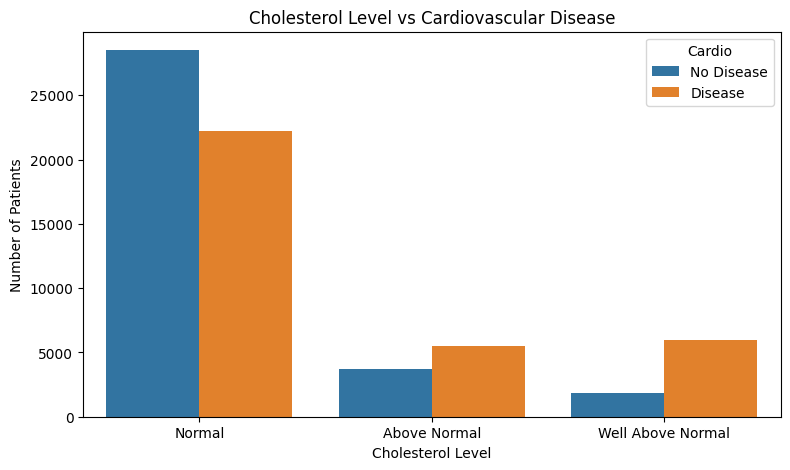

In [74]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="cholesterol",
    hue="cardio"
)

plt.title("Cholesterol Level vs Cardiovascular Disease")
plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1, 2],
    ["Normal", "Above Normal", "Well Above Normal"]
)

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.show()

In [75]:
# ==========================================
# GLUCOSE ANALYSIS
# ==========================================

glucose_cardio = pd.crosstab(
    df_clean["gluc"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(glucose_cardio.round(2))

cardio      0      1
gluc                
1       52.16  47.84
2       41.15  58.85
3       38.21  61.79


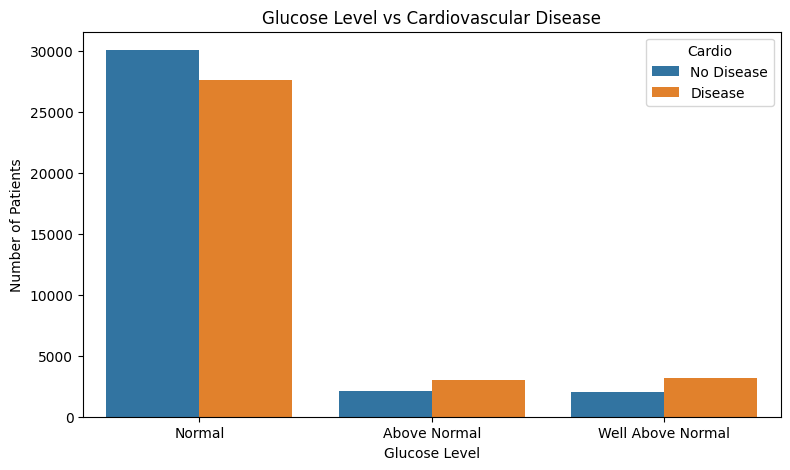

In [76]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="gluc",
    hue="cardio"
)

plt.title("Glucose Level vs Cardiovascular Disease")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1, 2],
    ["Normal", "Above Normal", "Well Above Normal"]
)

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.show()

In [78]:
# ==========================================
# SMOKING ANALYSIS
# ==========================================

smoke_cardio = pd.crosstab(
    df_clean["smoke"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(smoke_cardio.round(2))

cardio      0      1
smoke               
0       49.99  50.01
1       53.13  46.87


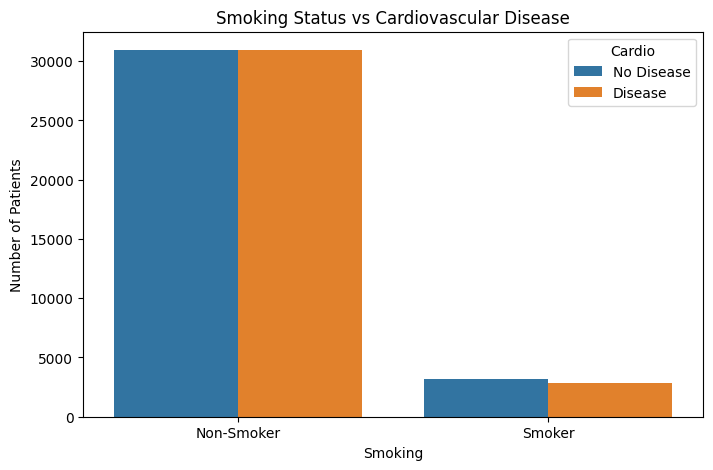

In [79]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="smoke",
    hue="cardio"
)

plt.title("Smoking Status vs Cardiovascular Disease")
plt.xlabel("Smoking")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["Non-Smoker", "Smoker"]
)

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.show()

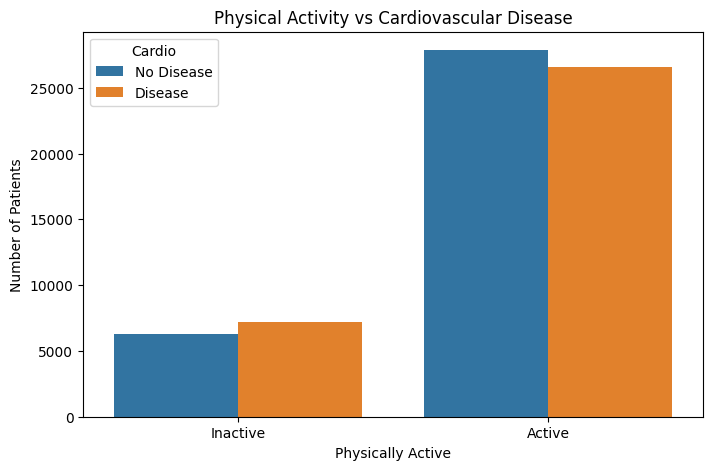

In [81]:
# ==========================================
# PHYSICAL ACTIVITY ANALYSIS
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="active",
    hue="cardio"
)

plt.title("Physical Activity vs Cardiovascular Disease")
plt.xlabel("Physically Active")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["Inactive", "Active"]
)

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.show()

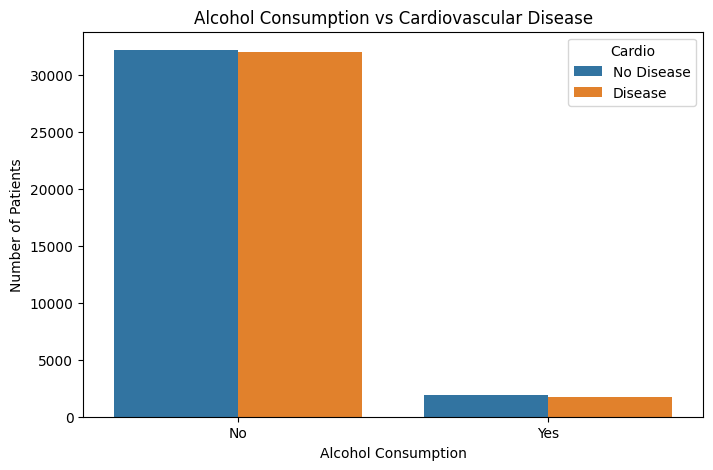

In [82]:
# ==========================================
# ALCOHOL ANALYSIS
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="alco",
    hue="cardio"
)

plt.title("Alcohol Consumption vs Cardiovascular Disease")
plt.xlabel("Alcohol Consumption")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.legend(
    title="Cardio",
    labels=["No Disease", "Disease"]
)

plt.show()

In [83]:
# ==========================================
# BMI CATEGORY ANALYSIS
# ==========================================

bmi_percentage = pd.crosstab(
    df_clean["bmi_category"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(bmi_percentage.round(2))

cardio            0      1
bmi_category              
Normal        59.93  40.07
Obese         37.48  62.52
Overweight    49.29  50.71
Underweight   72.73  27.27


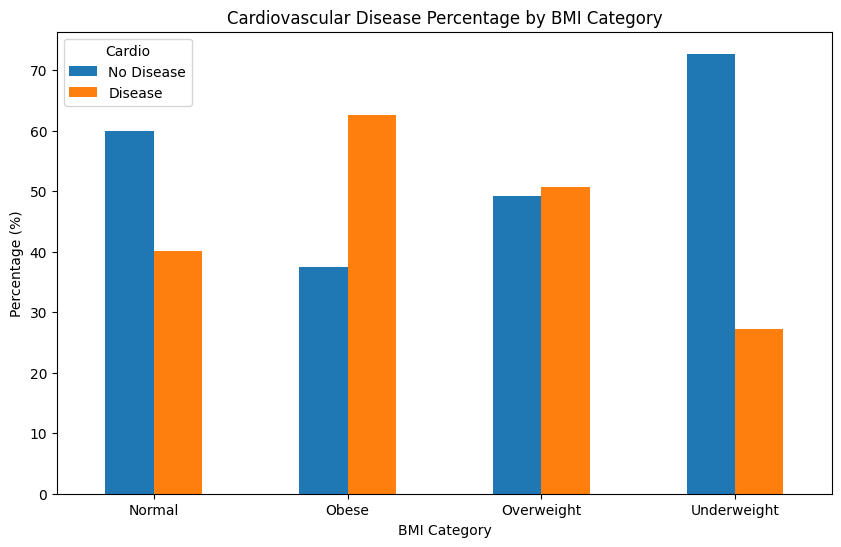

In [84]:
bmi_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cardiovascular Disease Percentage by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["No Disease", "Disease"],
    title="Cardio"
)

plt.show()

In [86]:
# ==========================================
# AGE GROUP ANALYSIS
# ==========================================

age_percentage = pd.crosstab(
    df_clean["age_group"],
    df_clean["cardio"],
    normalize="index"
) * 100

print(age_percentage.round(2))

cardio           0      1
age_group                
Middle Age   58.36  41.64
Senior       39.29  60.71
Young Adult  75.63  24.37


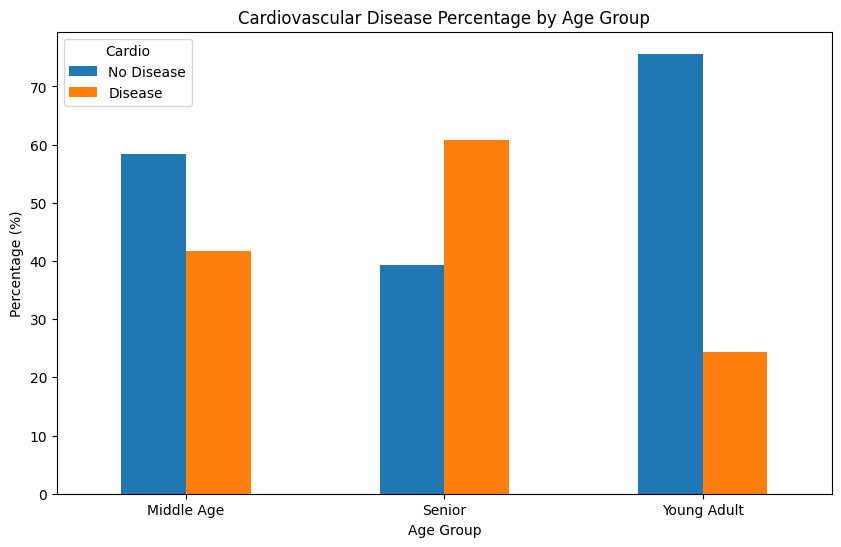

In [87]:
age_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cardiovascular Disease Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["No Disease", "Disease"],
    title="Cardio"
)

plt.show()

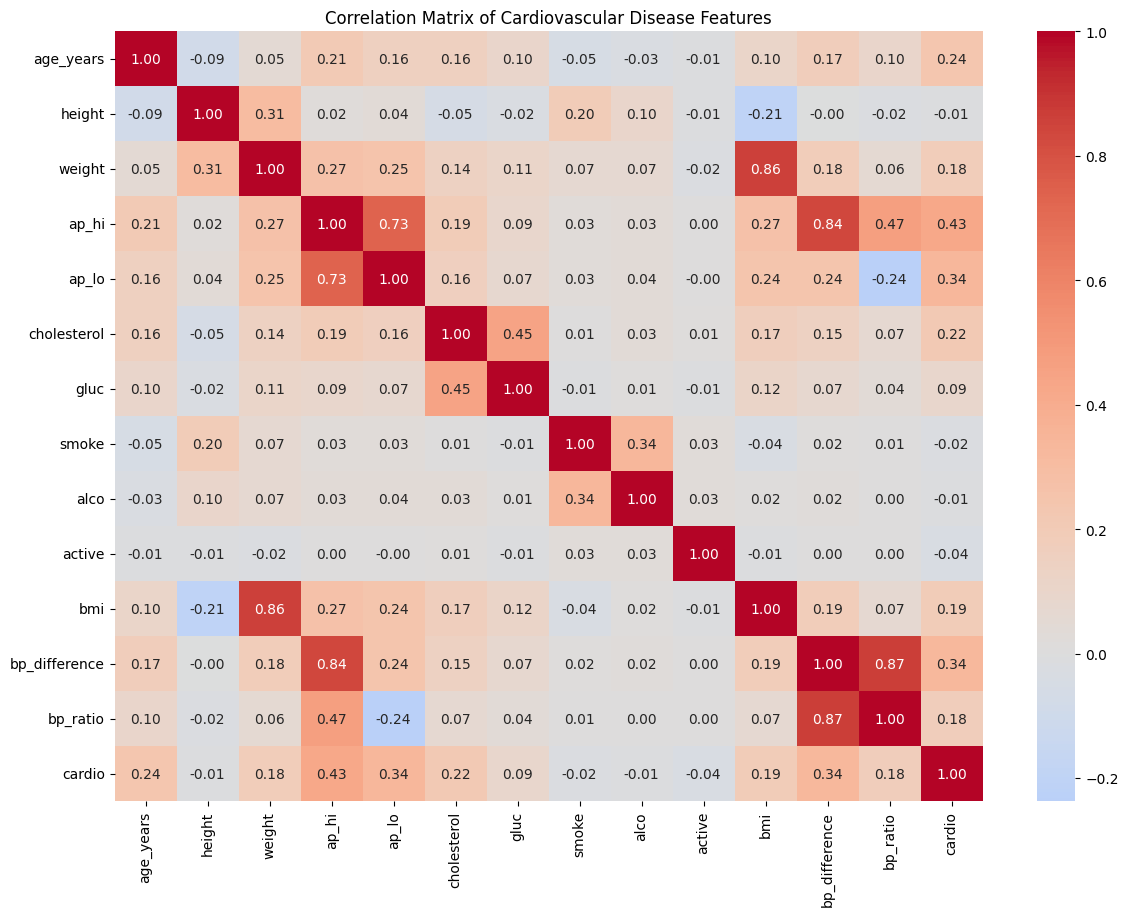

In [89]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

numeric_columns = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "bp_difference",
    "bp_ratio",
    "cardio"
]

correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Cardiovascular Disease Features")

plt.show()

In [92]:
# ==========================================
# TARGET CORRELATIONS
# ==========================================

target_correlation = (
    correlation_matrix["cardio"]
    .sort_values(ascending=False)
)

print("Correlation with cardiovascular disease:")
print(target_correlation)

Correlation with cardiovascular disease:
cardio           1.000000
ap_hi            0.428027
ap_lo            0.341042
bp_difference    0.336365
age_years        0.238837
cholesterol      0.220067
bmi              0.189691
weight           0.179466
bp_ratio         0.175373
gluc             0.088136
alco            -0.009662
height          -0.011700
smoke           -0.017820
active          -0.036074
Name: cardio, dtype: float64


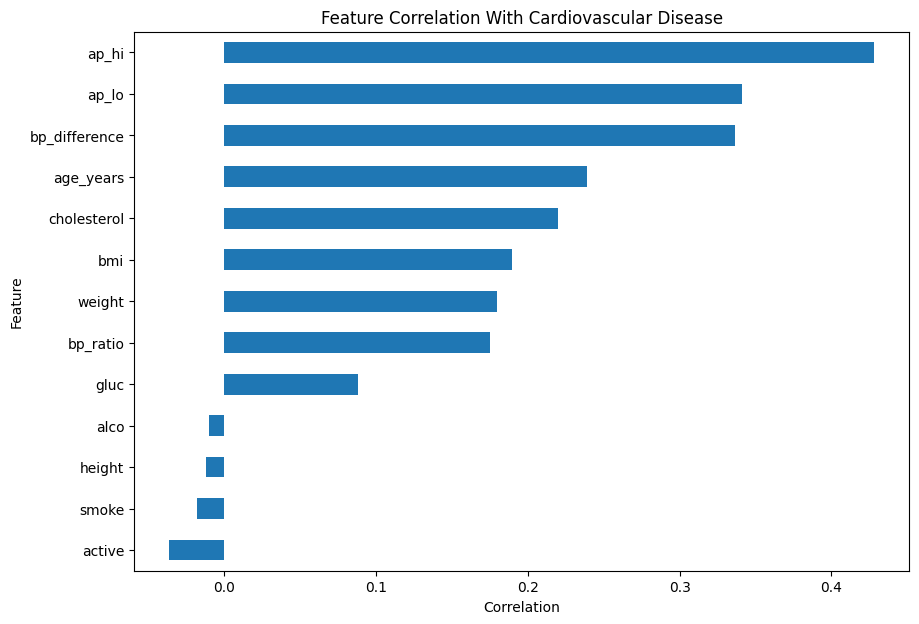

In [93]:
plt.figure(figsize=(10, 7))

target_correlation.drop("cardio").sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation With Cardiovascular Disease")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

**7. Feature and Target Selection**

In [94]:
# ==========================================
# REVIEW FEATURES
# ==========================================

print("Current columns:")
print(df_clean.columns.tolist())

Current columns:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_difference', 'bp_ratio', 'age_group', 'bmi_category']


In [95]:
# ==========================================
# SELECT FEATURES
# ==========================================

feature_columns = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "bp_difference",
    "bp_ratio"
]

print("Selected features:")
for feature in feature_columns:
    print("-", feature)

Selected features:
- age_years
- gender
- height
- weight
- ap_hi
- ap_lo
- cholesterol
- gluc
- smoke
- alco
- active
- bmi
- bp_difference
- bp_ratio


In [96]:
# ==========================================
# CREATE X AND y
# ==========================================

X = df_clean[feature_columns]

y = df_clean["cardio"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (67907, 14)
y shape: (67907,)


In [97]:
# Display the first 5 feature records
display(X.head())

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
0,50.4,2,168,62.0,110,80,1,1,0,0,1,21.97,30,1.38
1,55.4,1,156,85.0,140,90,3,1,0,0,1,34.93,50,1.56
2,51.6,1,165,64.0,130,70,3,1,0,0,0,23.51,60,1.86
3,48.2,2,169,82.0,150,100,1,1,0,0,1,28.71,50,1.50
4,47.8,1,156,56.0,100,60,1,1,0,0,0,23.01,40,1.67


In [99]:
# Display target values
display(y.head(10))

,cardio
0,0
1,1
2,1
3,1
4,0
5,0
6,0
7,1
8,0
9,0


In [101]:
# ==========================================
# TARGET BALANCE
# ==========================================

print("Target counts:")
print(y.value_counts())

print("\nTarget percentages:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target counts:
cardio
0    34138
1    33769
Name: count, dtype: int64

Target percentages:
cardio
0    50.27
1    49.73
Name: proportion, dtype: float64


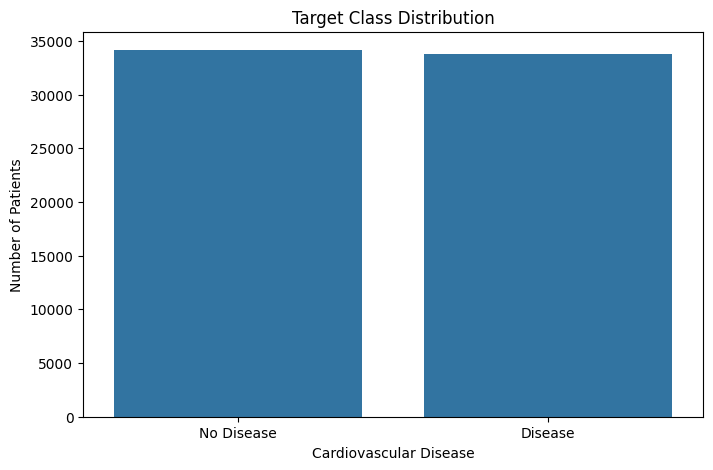

In [102]:
plt.figure(figsize=(8, 5))

sns.countplot(x=y)

plt.title("Target Class Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

In [104]:
# ==========================================
# CHECK DATA TYPES


print(X.dtypes)

age_years        float64
gender             int64
height             int64
weight           float64
ap_hi              int64
ap_lo              int64
cholesterol        int64
gluc               int64
smoke              int64
alco               int64
active             int64
bmi              float64
bp_difference      int64
bp_ratio         float64
dtype: object


In [105]:
# ==========================================
# FINAL MISSING VALUE CHECK
# ==========================================

print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
age_years        0
gender           0
height           0
weight           0
ap_hi            0
ap_lo            0
cholesterol      0
gluc             0
smoke            0
alco             0
active           0
bmi              0
bp_difference    0
bp_ratio         0
dtype: int64

Missing values in y:
0


In [106]:
# ==========================================
# CHECK INFINITE VALUES
# ==========================================

print("Infinite values in X:")

print(
    np.isinf(X.select_dtypes(include=np.number))
    .sum()
)

Infinite values in X:
age_years        0
gender           0
height           0
weight           0
ap_hi            0
ap_lo            0
cholesterol      0
gluc             0
smoke            0
alco             0
active           0
bmi              0
bp_difference    0
bp_ratio         0
dtype: int64


In [107]:
# ==========================================
# FEATURE SUMMARY
# ==========================================

feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str),
    "Missing Values": X.isnull().sum().values,
    "Unique Values": X.nunique().values
})

display(feature_summary)

,Feature,Data Type,Missing Values,Unique Values
age_years,age_years,float64,0,263
gender,gender,int64,0,2
height,height,int64,0,72
weight,weight,float64,0,264
ap_hi,ap_hi,int64,0,105
ap_lo,ap_lo,int64,0,78
cholesterol,cholesterol,int64,0,3
gluc,gluc,int64,0,3
smoke,smoke,int64,0,2
alco,alco,int64,0,2


In [108]:
# ==========================================
# STORE FEATURE LIST
# ==========================================

print("Number of features:", len(feature_columns))

print("\nFeatures used for machine learning:")
print(feature_columns)

Number of features: 14

Features used for machine learning:
['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_difference', 'bp_ratio']


**8. Train-Test Split**

Now we will divide our dataset into two parts:

Training data (80%) → used to train the machine-learning models.
Testing data (20%) → used only to evaluate how well the trained models perform on unseen data

In [109]:
X

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
0,50.4,2,168,62.0,110,80,1,1,0,0,1,21.97,30,1.38
1,55.4,1,156,85.0,140,90,3,1,0,0,1,34.93,50,1.56
2,51.6,1,165,64.0,130,70,3,1,0,0,0,23.51,60,1.86
3,48.2,2,169,82.0,150,100,1,1,0,0,1,28.71,50,1.50
4,47.8,1,156,56.0,100,60,1,1,0,0,0,23.01,40,1.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.7,2,168,76.0,120,80,1,1,1,0,1,26.93,40,1.50
69996,61.9,1,158,126.0,140,90,2,2,0,0,1,50.47,50,1.56
69997,52.2,2,183,105.0,180,90,3,1,0,1,0,31.35,90,2.00
69998,61.4,1,163,72.0,135,80,1,2,0,0,0,27.10,55,1.69


In [110]:
y

,cardio
0,0
1,1
2,1
3,1
4,0
...,...
69995,0
69996,1
69997,1
69998,1


In [112]:
# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and testing data created successfully!")

Training and testing data created successfully!


In [ ]:
test_size=0.20
random_state=42
stratify=y

In [114]:
# ==========================================
# CHECK DATASET SIZES
# ==========================================

print("Original dataset:")
print("X:", X.shape)
print("y:", y.shape)

print("\nTraining dataset:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting dataset:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Original dataset:
X: (67907, 14)
y: (67907,)

Training dataset:
X_train: (54325, 14)
y_train: (54325,)

Testing dataset:
X_test: (13582, 14)
y_test: (13582,)


In [117]:
# Check Target Distribution Before Splitting

original_distribution = (
    y.value_counts(normalize=True)
    .sort_index() * 100
)

print("Original target distribution:")
print(original_distribution.round(2))

Original target distribution:
cardio
0    50.27
1    49.73
Name: proportion, dtype: float64


In [118]:
# Check Training Target Distribution

train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index() * 100
)

print("Training target distribution:")
print(train_distribution.round(2))

Training target distribution:
cardio
0    50.27
1    49.73
Name: proportion, dtype: float64


In [119]:
# Check Testing Target Distribution

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index() * 100
)

print("Testing target distribution:")
print(test_distribution.round(2))

Testing target distribution:
cardio
0    50.27
1    49.73
Name: proportion, dtype: float64


In [120]:
# ==========================================
# COMPARE TARGET DISTRIBUTIONS
# ==========================================

distribution_comparison = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Training": y_train.value_counts(normalize=True),
    "Testing": y_test.value_counts(normalize=True)
}) * 100

distribution_comparison.index = [
    "No Disease",
    "Disease"
]

display(distribution_comparison.round(2))

,Original,Training,Testing
No Disease,50.27,50.27,50.27
Disease,49.73,49.73,49.73


In [122]:
# Verify There Is No Data Leakage

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (54325, 14)
X_test shape: (13582, 14)
y_train shape: (54325,)
y_test shape: (13582,)


**9. Feature Scaling**

In [123]:
from sklearn.preprocessing import StandardScaler

In [124]:
# ==========================================
# CREATE SCALER
# ==========================================

scaler = StandardScaler()

print("StandardScaler created successfully!")

StandardScaler created successfully!


In [125]:
# ==========================================
# FIT SCALER ON TRAINING DATA
# ==========================================

scaler.fit(X_train)

print("Scaler fitted using training data only!")

Scaler fitted using training data only!


In [126]:
# Transform Training and Testing Data

# ==========================================
# SCALE FEATURES
# ==========================================

X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (54325, 14)
Testing data scaled: (13582, 14)


In [127]:
#Convert Scaled Data Back to DataFrames

# ==========================================
# CREATE SCALED DATAFRAMES
# ==========================================

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns,
    index=X_test.index
)

display(X_train_scaled_df.head())

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
68029,-1.123839,-0.734401,-0.558947,1.672339,-0.402793,-0.138935,-0.538144,-0.395259,-0.310787,-0.238465,0.49525,2.073808,-0.463279,-0.419844
66281,0.976063,-0.734401,1.212031,0.338187,-0.402793,-0.138935,-0.538144,-0.395259,-0.310787,-0.238465,0.49525,-0.266683,-0.463279,-0.419844
24799,0.695090,-0.734401,-0.685446,-0.995965,-1.000667,-1.199074,-0.538144,-0.395259,3.217637,-0.238465,0.49525,-0.719805,-0.463279,0.048433
46435,-1.656209,-0.734401,0.579539,-0.855528,-0.402793,-1.199074,2.401788,3.095063,-0.310787,-0.238465,0.49525,-1.107646,0.390448,0.984987
2340,0.621149,-0.734401,-0.558947,5.323704,1.988704,-0.669004,-0.538144,-0.395259,-0.310787,-0.238465,0.49525,5.973345,3.378492,3.794650


In [129]:
# ==========================================
# COMPARE ORIGINAL VS SCALED
# ==========================================

print("Original training data:")
display(X_train.head())

print("\nScaled training data:")
display(X_train_scaled_df.head())

Original training data:


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
68029,45.7,1,160,98.0,120,80,1,1,0,0,1,38.28,40,1.50
66281,59.9,1,174,79.0,120,80,1,1,0,0,1,26.09,40,1.50
24799,58.0,1,159,60.0,110,70,1,1,1,0,1,23.73,40,1.57
46435,42.1,1,169,62.0,120,70,3,3,0,0,1,21.71,50,1.71
2340,57.5,1,160,150.0,160,75,1,1,0,0,1,58.59,85,2.13



Scaled training data:


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
68029,-1.123839,-0.734401,-0.558947,1.672339,-0.402793,-0.138935,-0.538144,-0.395259,-0.310787,-0.238465,0.49525,2.073808,-0.463279,-0.419844
66281,0.976063,-0.734401,1.212031,0.338187,-0.402793,-0.138935,-0.538144,-0.395259,-0.310787,-0.238465,0.49525,-0.266683,-0.463279,-0.419844
24799,0.695090,-0.734401,-0.685446,-0.995965,-1.000667,-1.199074,-0.538144,-0.395259,3.217637,-0.238465,0.49525,-0.719805,-0.463279,0.048433
46435,-1.656209,-0.734401,0.579539,-0.855528,-0.402793,-1.199074,2.401788,3.095063,-0.310787,-0.238465,0.49525,-1.107646,0.390448,0.984987
2340,0.621149,-0.734401,-0.558947,5.323704,1.988704,-0.669004,-0.538144,-0.395259,-0.310787,-0.238465,0.49525,5.973345,3.378492,3.794650


In [130]:
# ==========================================
# CHECK SCALED MEANS
# ==========================================

scaled_means = X_train_scaled_df.mean()

print("Mean of scaled training features:")
print(scaled_means.round(4))

Mean of scaled training features:
age_years       -0.0
gender          -0.0
height           0.0
weight          -0.0
ap_hi           -0.0
ap_lo            0.0
cholesterol      0.0
gluc             0.0
smoke            0.0
alco             0.0
active           0.0
bmi             -0.0
bp_difference   -0.0
bp_ratio         0.0
dtype: float64


In [131]:
# ==========================================
# CHECK SCALED STANDARD DEVIATION
# ==========================================

scaled_std = X_train_scaled_df.std()

print("Standard deviation of scaled training features:")
print(scaled_std.round(4))

Standard deviation of scaled training features:
age_years        1.0
gender           1.0
height           1.0
weight           1.0
ap_hi            1.0
ap_lo            1.0
cholesterol      1.0
gluc             1.0
smoke            1.0
alco             1.0
active           1.0
bmi              1.0
bp_difference    1.0
bp_ratio         1.0
dtype: float64


In [132]:
# Check the Testing Data

scaler.transform(X_test)

array([[-1.74493728, -0.73440065,  0.45304018, ..., -0.92140562,
        -0.46327867, -0.4198443 ],
       [ 0.36975278,  1.36165458,  1.08553233, ...,  0.30547989,
        -0.46327867, -1.35639865],
       [ 0.99085056, -0.73440065, -0.17945196, ..., -0.72364473,
        -0.46327867, -0.4198443 ],
       ...,
       [ 0.87254622, -0.73440065, -2.58292213, ...,  0.64916144,
         1.24417518,  1.25257418],
       [ 0.05920389, -0.73440065, -0.81194411, ...,  2.95317179,
        -0.46327867, -1.55708887],
       [-1.64142098, -0.73440065, -0.93844254, ..., -0.44716349,
        -1.31700559, -1.22260517]])

In [134]:
print("Scaled testing data:")
display(X_test_scaled_df.head())

Scaled testing data:


,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
45945,-1.744937,-0.734401,0.453040,-0.715091,-0.402793,-0.138935,2.401788,-0.395259,-0.310787,-0.238465,0.495250,-0.921406,-0.463279,-0.419844
60965,0.369753,1.361655,1.085532,0.899935,1.390830,3.041480,-0.538144,1.349902,-0.310787,-0.238465,0.495250,0.305480,-0.463279,-1.356399
27400,0.990851,-0.734401,-0.179452,-0.785310,-0.402793,-0.138935,2.401788,3.095063,-0.310787,-0.238465,-2.019184,-0.723645,-0.463279,-0.419844
41535,-0.872443,-0.734401,-2.076928,-0.995965,-0.402793,-0.138935,0.931822,-0.395259,-0.310787,-0.238465,0.495250,-0.017082,-0.463279,-0.419844
21150,-0.147829,-0.734401,-1.950430,-1.698151,-1.000667,-1.199074,0.931822,-0.395259,-0.310787,-0.238465,0.495250,-0.952126,-0.463279,0.048433


In [135]:
# Keep Both Versions

X_train

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
68029,45.7,1,160,98.0,120,80,1,1,0,0,1,38.28,40,1.50
66281,59.9,1,174,79.0,120,80,1,1,0,0,1,26.09,40,1.50
24799,58.0,1,159,60.0,110,70,1,1,1,0,1,23.73,40,1.57
46435,42.1,1,169,62.0,120,70,3,3,0,0,1,21.71,50,1.71
2340,57.5,1,160,150.0,160,75,1,1,0,0,1,58.59,85,2.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7315,56.1,1,162,87.0,180,100,1,1,0,0,1,33.15,80,1.80
18469,52.2,1,169,94.0,90,60,1,1,1,0,1,32.91,30,1.50
16455,53.6,2,158,68.0,120,80,1,1,0,0,1,27.24,40,1.50
35681,59.7,2,170,98.0,110,70,1,1,1,1,1,33.91,40,1.57


In [136]:
X_test

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
45945,41.5,1,168,64.0,120,80,3,1,0,0,1,22.68,40,1.50
60965,55.8,2,173,87.0,150,110,1,2,0,0,1,29.07,40,1.36
27400,60.0,1,163,63.0,120,80,3,3,0,0,0,23.71,40,1.50
41535,47.4,1,148,60.0,120,80,2,1,0,0,1,27.39,40,1.50
21150,52.3,1,149,50.0,110,70,2,1,0,0,1,22.52,40,1.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13601,57.6,1,160,62.0,160,90,1,1,0,0,1,24.22,70,1.78
47030,60.1,1,155,57.0,120,80,2,1,0,0,1,23.73,40,1.50
64956,59.2,1,144,64.0,140,80,3,3,0,0,0,30.86,60,1.75
30292,53.7,1,158,107.0,160,120,2,2,0,0,0,42.86,40,1.33


In [137]:
X_train_scaled

array([[-1.1238395 , -0.73440065, -0.55894725, ...,  2.07380784,
        -0.46327867, -0.4198443 ],
       [ 0.97606252, -0.73440065,  1.21203076, ..., -0.26668268,
        -0.46327867, -0.4198443 ],
       [ 0.69508971, -0.73440065, -0.68544568, ..., -0.71980471,
        -0.46327867,  0.04843287],
       ...,
       [ 0.04441585,  1.36165458, -0.81194411, ..., -0.04588169,
        -0.46327867, -0.4198443 ],
       [ 0.94648643,  1.36165458,  0.70603704, ...,  1.23476407,
        -0.46327867,  0.04843287],
       [-1.16820362, -0.73440065,  0.45304018, ..., -1.33036746,
        -0.46327867, -0.4198443 ]])

In [138]:
X_test_scaled

array([[-1.74493728, -0.73440065,  0.45304018, ..., -0.92140562,
        -0.46327867, -0.4198443 ],
       [ 0.36975278,  1.36165458,  1.08553233, ...,  0.30547989,
        -0.46327867, -1.35639865],
       [ 0.99085056, -0.73440065, -0.17945196, ..., -0.72364473,
        -0.46327867, -0.4198443 ],
       ...,
       [ 0.87254622, -0.73440065, -2.58292213, ...,  0.64916144,
         1.24417518,  1.25257418],
       [ 0.05920389, -0.73440065, -0.81194411, ...,  2.95317179,
        -0.46327867, -1.55708887],
       [-1.64142098, -0.73440065, -0.93844254, ..., -0.44716349,
        -1.31700559, -1.22260517]])

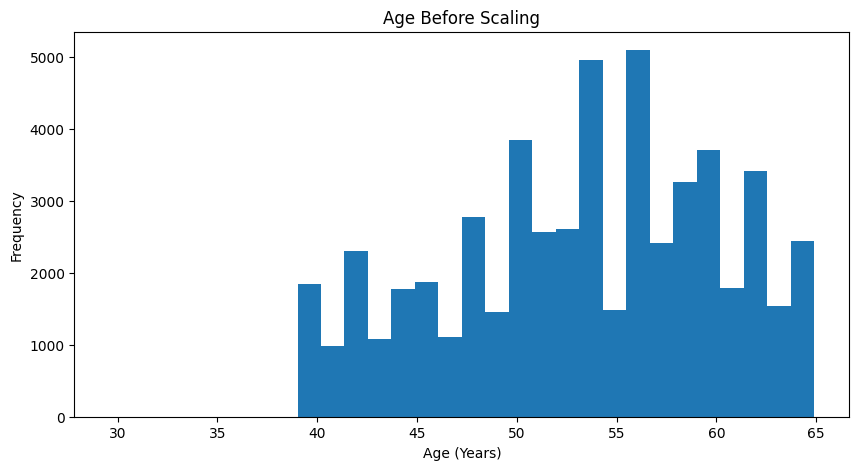

In [139]:
# Optional Visualization of Scaling

plt.figure(figsize=(10, 5))

plt.hist(
    X_train["age_years"],
    bins=30
)

plt.title("Age Before Scaling")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")

plt.show()


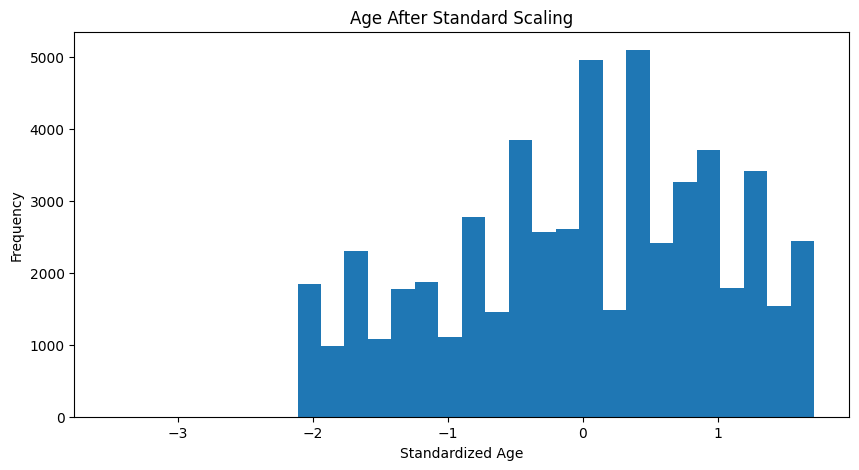

In [140]:
plt.figure(figsize=(10, 5))

plt.hist(
    X_train_scaled_df["age_years"],
    bins=30
)

plt.title("Age After Standard Scaling")
plt.xlabel("Standardized Age")
plt.ylabel("Frequency")

plt.show()

**10. Model Training**

We'll train six different models:

Logistic Regression,
Decision Tree,
Random Forest,
K-Nearest Neighbors,
Support Vector Machine,
Gradient Boosting

In [141]:
# ==========================================
# CREATE MACHINE LEARNING MODELS
# ==========================================

# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# K-Nearest Neighbors
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Support Vector Machine
svm_model = SVC(
    probability=True,
    random_state=42
)

# Gradient Boosting
gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

print("All models created successfully!")

All models created successfully!


In [142]:
# ==========================================
# LOGISTIC REGRESSION
# ==========================================

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [143]:
# ==========================================
# LOGISTIC REGRESSION PREDICTIONS
# ==========================================

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [144]:
# Train Decision Tree

# Decision Trees don't require feature scaling.

X_train

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,bmi,bp_difference,bp_ratio
68029,45.7,1,160,98.0,120,80,1,1,0,0,1,38.28,40,1.50
66281,59.9,1,174,79.0,120,80,1,1,0,0,1,26.09,40,1.50
24799,58.0,1,159,60.0,110,70,1,1,1,0,1,23.73,40,1.57
46435,42.1,1,169,62.0,120,70,3,3,0,0,1,21.71,50,1.71
2340,57.5,1,160,150.0,160,75,1,1,0,0,1,58.59,85,2.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7315,56.1,1,162,87.0,180,100,1,1,0,0,1,33.15,80,1.80
18469,52.2,1,169,94.0,90,60,1,1,1,0,1,32.91,30,1.50
16455,53.6,2,158,68.0,120,80,1,1,0,0,1,27.24,40,1.50
35681,59.7,2,170,98.0,110,70,1,1,1,1,1,33.91,40,1.57


In [145]:
# ==========================================
# DECISION TREE
# ==========================================

print("Training Decision Tree...")

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed!")

Training Decision Tree...
Decision Tree training completed!


In [146]:
decision_tree_predictions = decision_tree_model.predict(
    X_test
)

decision_tree_probabilities = decision_tree_model.predict_proba(
    X_test
)[:, 1]

print("Decision Tree predictions generated!")

Decision Tree predictions generated!


In [147]:
# ==========================================
# RANDOM FOREST
# ==========================================

print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [148]:
random_forest_predictions = random_forest_model.predict(
    X_test
)

random_forest_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [149]:
# ==========================================
# K-NEAREST NEIGHBORS
# ==========================================
# KNN is sensitive to feature scale, so we'll use the scaled data.

print("Training K-Nearest Neighbors...")

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN training completed!")

Training K-Nearest Neighbors...
KNN training completed!


In [150]:
knn_predictions = knn_model.predict(
    X_test_scaled
)

knn_probabilities = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

print("KNN predictions generated!")

KNN predictions generated!


In [151]:
# ==========================================
# SECTION 11.7: SUPPORT VECTOR MACHINE
# ==========================================

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

print("Linear SVM model created!")

Linear SVM model created!


In [152]:
# Train the model

print("Training Support Vector Machine...")

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM training completed!")

Training Support Vector Machine...
SVM training completed!


In [153]:
# ==========================================
# LINEAR SVM PREDICTIONS
# ==========================================

svm_predictions = svm_model.predict(
    X_test_scaled
)

svm_scores = svm_model.decision_function(
    X_test_scaled
)

print("Linear SVM predictions generated!")

Linear SVM predictions generated!


In [154]:
# ==========================================
# GRADIENT BOOSTING
# ==========================================

print("Training Gradient Boosting...")

gradient_boosting_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting training completed!")

Training Gradient Boosting...
Gradient Boosting training completed!


In [156]:
gradient_boosting_predictions = gradient_boosting_model.predict(
    X_test
)

gradient_boosting_probabilities = (
    gradient_boosting_model.predict_proba(X_test)[:, 1]
)

print("Gradient Boosting predictions generated!")

Gradient Boosting predictions generated!


In [157]:
# ==========================================
# VERIFY PREDICTIONS
# ==========================================

print("Logistic Regression:", len(logistic_predictions))
print("Decision Tree:", len(decision_tree_predictions))
print("Random Forest:", len(random_forest_predictions))
print("KNN:", len(knn_predictions))
print("SVM:", len(svm_predictions))
print("Gradient Boosting:", len(gradient_boosting_predictions))

Logistic Regression: 13582
Decision Tree: 13582
Random Forest: 13582
KNN: 13582
SVM: 13582
Gradient Boosting: 13582


In [158]:
len(y_test)

13582

In [159]:
print("Number of test samples:", len(y_test))

Number of test samples: 13582


In [160]:
# ==========================================
# PREDICTION COMPARISON
# ==========================================

predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "KNN": knn_predictions,
    "SVM": svm_predictions,
    "Gradient Boosting": gradient_boosting_predictions
})

display(predictions_df.head(10))

,Actual,Logistic Regression,Decision Tree,Random Forest,KNN,SVM,Gradient Boosting
0,0,0,0,1,1,0,1
1,1,1,1,1,1,1,1
2,1,1,0,0,0,1,1
3,1,0,1,0,0,0,0
4,1,0,0,0,0,0,0
5,1,0,1,0,0,0,0
6,1,1,1,1,1,1,1
7,0,0,0,0,0,0,0
8,0,0,1,1,0,0,0
9,0,1,0,1,1,1,1


In [161]:
# ==========================================
# MODEL DICTIONARY
# ==========================================

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Gradient Boosting": gradient_boosting_model
}

print("Models stored:")
for name in models:
    print("-", name)

Models stored:
- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- SVM
- Gradient Boosting


In [162]:
# ==========================================
# PREDICTION DICTIONARIES
# ==========================================

predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "KNN": knn_predictions,
    "SVM": svm_predictions,
    "Gradient Boosting": gradient_boosting_predictions
}

probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": decision_tree_probabilities,
    "Random Forest": random_forest_probabilities,
    "KNN": knn_probabilities,
    "Gradient Boosting": gradient_boosting_probabilities
}
svm_scores = svm_model.decision_function(X_test_scaled)
print("Predictions and probabilities stored successfully!")

Predictions and probabilities stored successfully!


In [163]:
# ==========================================
# INITIAL ACCURACY
# ==========================================

for name, prediction in predictions.items():
    accuracy = accuracy_score(y_test, prediction)

    print(
        f"{name}: {accuracy:.4f}"
    )

Logistic Regression: 0.7242
Decision Tree: 0.6205
Random Forest: 0.7062
KNN: 0.6945
SVM: 0.7229
Gradient Boosting: 0.7303


**11. Model Comparison**

In [164]:
# ==========================================
# IMPORT EVALUATION METRICS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [166]:
# ==========================================
# CALCULATE MODEL METRICS
# ==========================================

results = []

for name in predictions:

    y_pred = predictions[name]

    # Calculate basic classification metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # Calculate ROC-AUC
    if name == "SVM":
        roc_auc = roc_auc_score(
            y_test,
            svm_scores
        )
    else:
        y_prob = probabilities[name]

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

In [167]:
# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Gradient Boosting,0.7303,0.7475,0.6911,0.7182,0.7978
0,Logistic Regression,0.7242,0.7484,0.6709,0.7075,0.7880
4,SVM,0.7229,0.7513,0.6618,0.7037,0.7876
2,Random Forest,0.7062,0.7077,0.6972,0.7024,0.7642
3,KNN,0.6945,0.6975,0.6811,0.6892,0.7436
1,Decision Tree,0.6205,0.6171,0.6244,0.6207,0.6205


In [168]:
# ==========================================
# RESULTS AS PERCENTAGES
# ==========================================

results_percentage = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_percentage[metric_columns] = (
    results_percentage[metric_columns] * 100
).round(2)

display(results_percentage)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Gradient Boosting,73.03,74.75,69.11,71.82,79.78
0,Logistic Regression,72.42,74.84,67.09,70.75,78.80
4,SVM,72.29,75.13,66.18,70.37,78.76
2,Random Forest,70.62,70.77,69.72,70.24,76.42
3,KNN,69.45,69.75,68.11,68.92,74.36
1,Decision Tree,62.05,61.71,62.44,62.07,62.05


In [169]:
# ==========================================
# BEST MODEL BY METRIC
# ==========================================

for metric in metric_columns:

    best_model = results_df.loc[
        results_df[metric].idxmax(),
        "Model"
    ]

    best_score = results_df[metric].max()

    print(
        f"Best {metric}: "
        f"{best_model} ({best_score:.4f})"
    )

Best Accuracy: Gradient Boosting (0.7303)
Best Precision: SVM (0.7513)
Best Recall: Random Forest (0.6972)
Best F1 Score: Gradient Boosting (0.7182)
Best ROC-AUC: Gradient Boosting (0.7978)


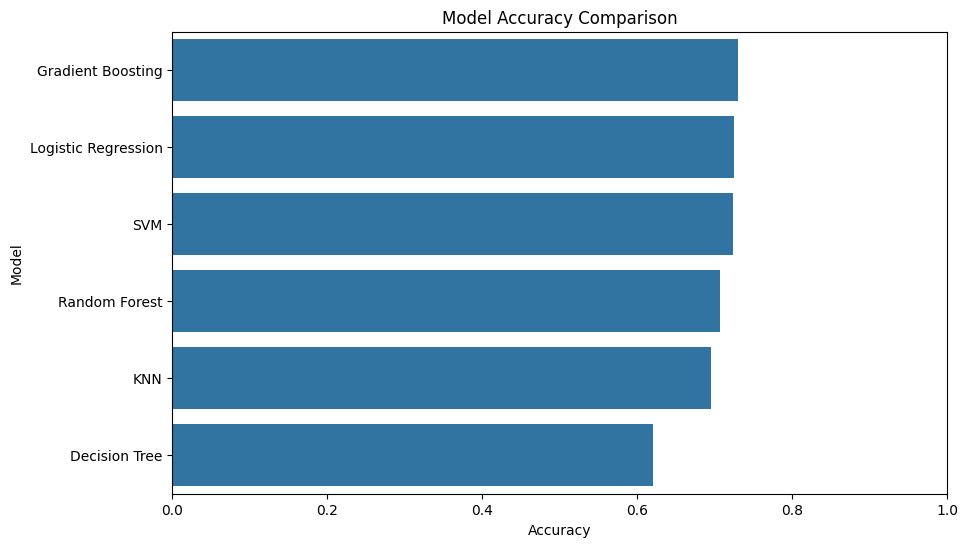

In [170]:
# ==========================================
# ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

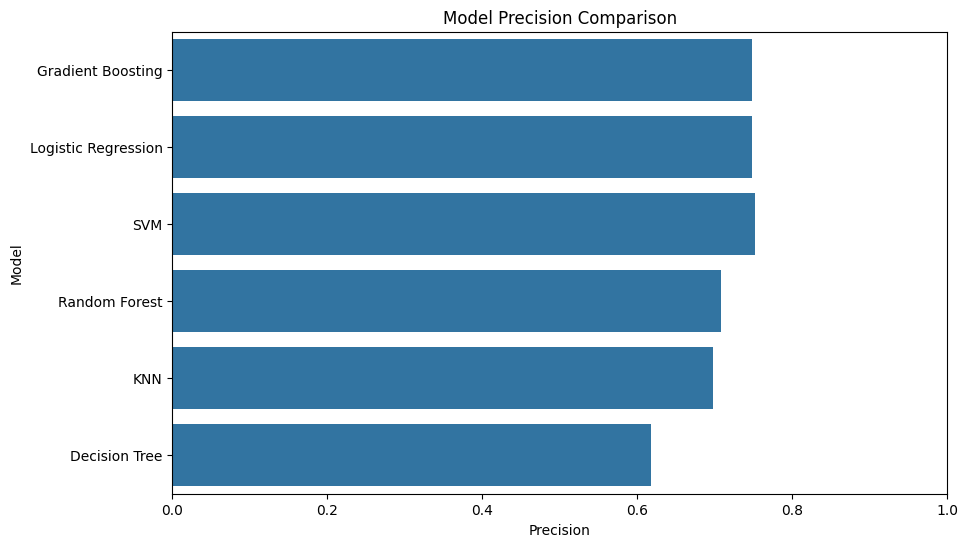

In [171]:
# ==========================================
# PRECISION COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Precision",
    y="Model"
)

plt.title("Model Precision Comparison")
plt.xlabel("Precision")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

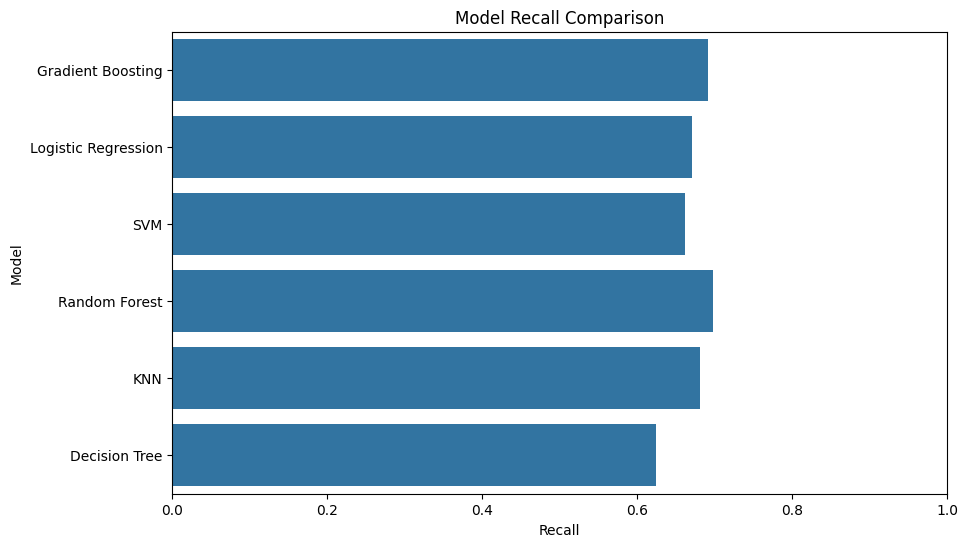

In [172]:
# ==========================================
# RECALL COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Recall",
    y="Model"
)

plt.title("Model Recall Comparison")
plt.xlabel("Recall")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

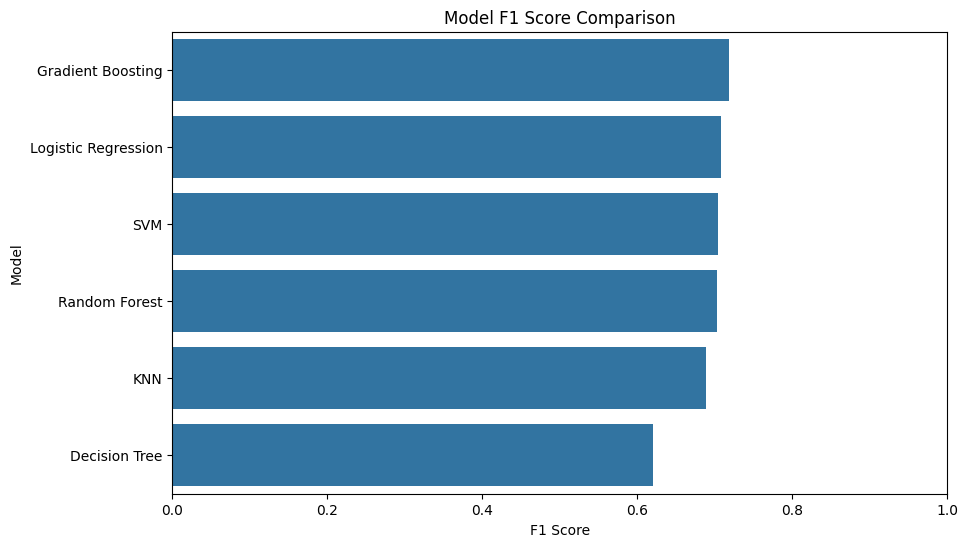

In [173]:
# ==========================================
# F1 SCORE COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title("Model F1 Score Comparison")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

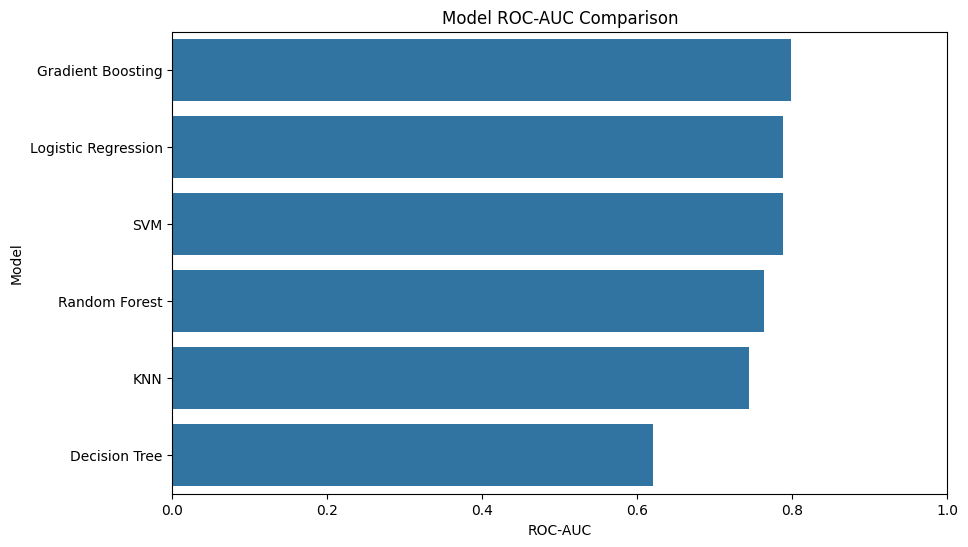

In [174]:
# ==========================================
# ROC-AUC COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model"
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

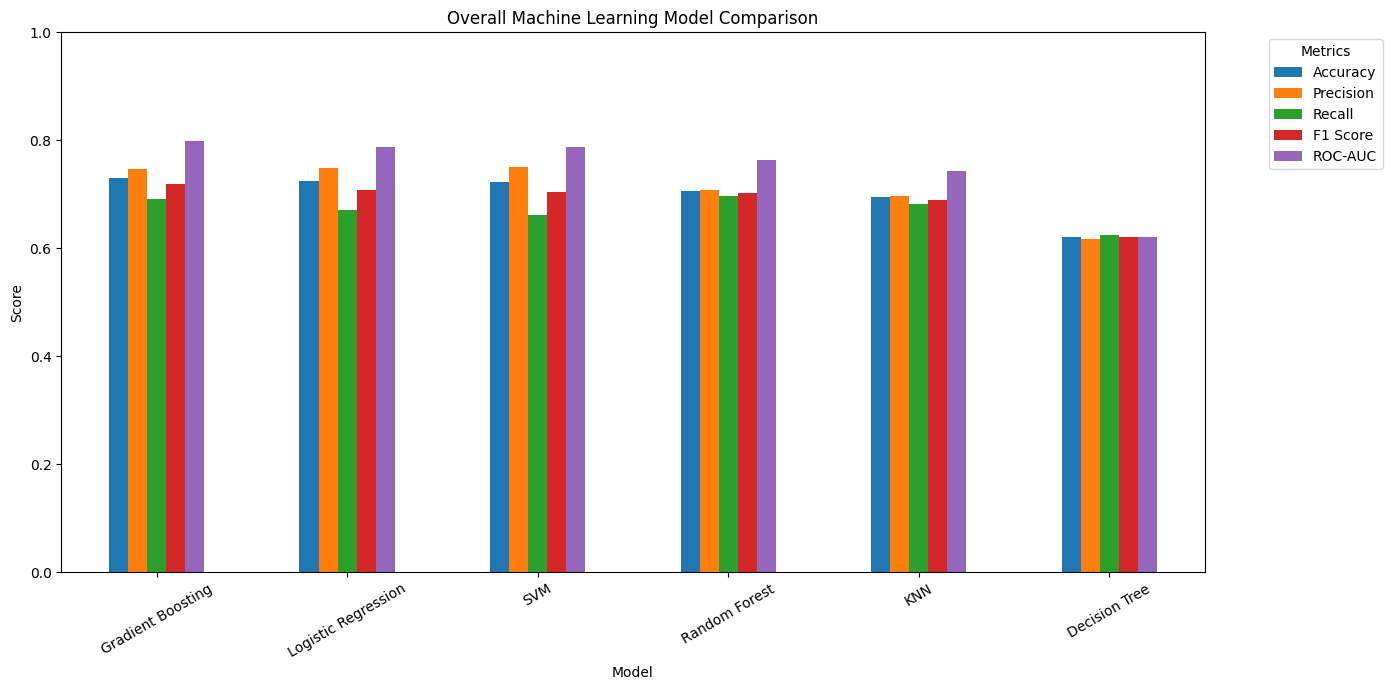

In [175]:
# ==========================================
# COMBINED MODEL COMPARISON
# ==========================================

plot_data = results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

plot_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Overall Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

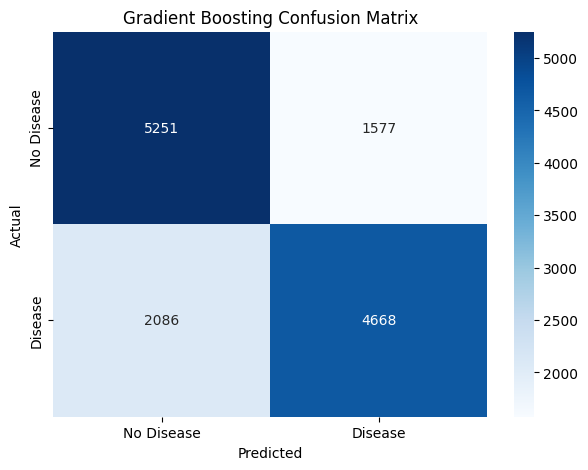

In [176]:
# ==========================================
# GRADIENT BOOSTING CONFUSION MATRIX
# ==========================================

gb_cm = confusion_matrix(
    y_test,
    gradient_boosting_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [177]:
# ==========================================
# GRADIENT BOOSTING REPORT
# ==========================================

print(
    classification_report(
        y_test,
        gradient_boosting_predictions,
        target_names=[
            "No Disease",
            "Disease"
        ]
    )
)

              precision    recall  f1-score   support

  No Disease       0.72      0.77      0.74      6828
     Disease       0.75      0.69      0.72      6754

    accuracy                           0.73     13582
   macro avg       0.73      0.73      0.73     13582
weighted avg       0.73      0.73      0.73     13582



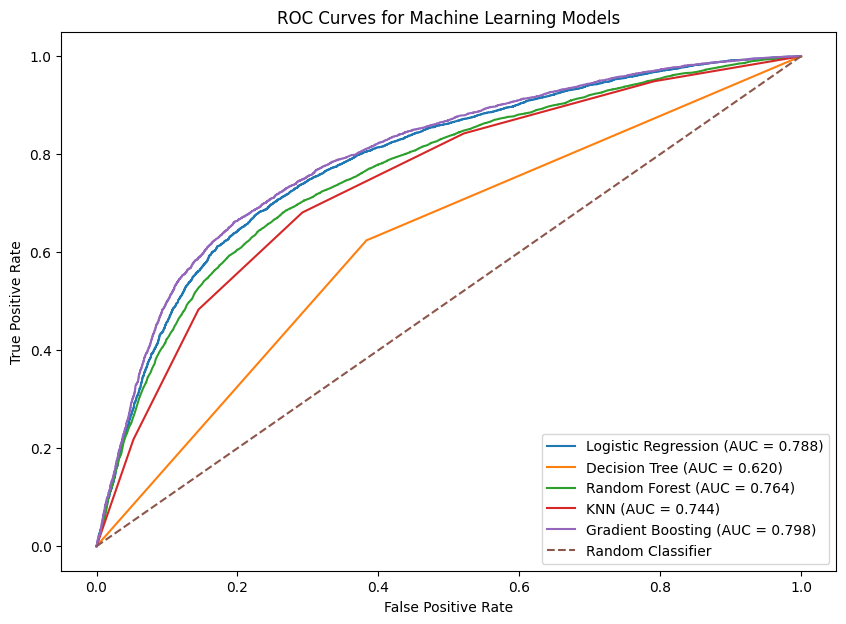

In [178]:
# ==========================================
# ROC CURVES
# ==========================================

plt.figure(figsize=(10, 7))

for name in probabilities:

    y_prob = probabilities[name]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves for Machine Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(
    loc="lower right"
)

plt.show()

In [179]:
# ==========================================
# BEST MODELS
# ==========================================

for metric in metric_columns:

    row = results_df.loc[
        results_df[metric].idxmax()
    ]

    print(
        f"{metric}: "
        f"{row['Model']} → "
        f"{row[metric]:.4f}"
    )

Accuracy: Gradient Boosting → 0.7303
Precision: SVM → 0.7513
Recall: Random Forest → 0.6972
F1 Score: Gradient Boosting → 0.7182
ROC-AUC: Gradient Boosting → 0.7978


In [180]:
# ==========================================
# FINAL COMPARISON TABLE
# ==========================================

final_comparison = results_df.copy()

final_comparison = final_comparison.round(4)

display(final_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Gradient Boosting,0.7303,0.7475,0.6911,0.7182,0.7978
0,Logistic Regression,0.7242,0.7484,0.6709,0.7075,0.7880
4,SVM,0.7229,0.7513,0.6618,0.7037,0.7876
2,Random Forest,0.7062,0.7077,0.6972,0.7024,0.7642
3,KNN,0.6945,0.6975,0.6811,0.6892,0.7436
1,Decision Tree,0.6205,0.6171,0.6244,0.6207,0.6205


**12. Hyperparameter Tuning**

Decision

Gradient Boosting is clearly the strongest baseline model because it has:

Highest Accuracy: 73.03%
Highest F1 Score: 71.82%
Highest ROC-AUC: 79.78%

Random Forest has slightly higher recall, but Gradient Boosting performs better overall.

Therefore, we'll tune:

Gradient Boosting — primary candidate,
Random Forest — secondary candidate,
Optionally compare the tuned results afterward

In [181]:
# ==========================================
# IMPORT HYPERPARAMETER TOOLS
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

In [182]:
# ==========================================
# GRADIENT BOOSTING PARAMETERS
# ==========================================

gb_param_grid = {
    "n_estimators": [100, 200, 300, 400],

    "learning_rate": [
        0.01,
        0.05,
        0.1,
        0.15
    ],

    "max_depth": [
        2,
        3,
        4,
        5
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "subsample": [
        0.8,
        0.9,
        1.0
    ]
}

In [183]:
# ==========================================
# BASE GRADIENT BOOSTING MODEL
# ==========================================

gb_model = GradientBoostingClassifier(
    random_state=42
)

In [184]:
# ==========================================
# RANDOMIZED SEARCH
# ==========================================

gb_random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [185]:
# ==========================================
# FIT RANDOMIZED SEARCH
# ==========================================

print("Starting Gradient Boosting hyperparameter tuning...")

gb_random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed!")

Starting Gradient Boosting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Hyperparameter tuning completed!


In [186]:
# ==========================================
# BEST PARAMETERS
# ==========================================

print("Best Parameters:")

print(
    gb_random_search.best_params_
)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}


In [187]:
# ==========================================
# BEST Cross-Validation SCORE
# ==========================================

print(
    "Best Cross-Validation ROC-AUC:",
    round(
        gb_random_search.best_score_,
        4
    )
)

Best Cross-Validation ROC-AUC: 0.801


In [188]:
# ==========================================
# BEST GRADIENT BOOSTING MODEL
# ==========================================

best_gb_model = gb_random_search.best_estimator_

print(best_gb_model)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=4,
                           min_samples_split=5, n_estimators=200,
                           random_state=42, subsample=0.9)


In [189]:
# Evaluate the Tuned Model on the Test Set
# ==========================================
# TUNED MODEL PREDICTIONS
# ==========================================

tuned_gb_predictions = best_gb_model.predict(
    X_test
)

tuned_gb_probabilities = best_gb_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [190]:
# ==========================================
# TUNED MODEL METRICS
# ==========================================

tuned_gb_accuracy = accuracy_score(
    y_test,
    tuned_gb_predictions
)

tuned_gb_precision = precision_score(
    y_test,
    tuned_gb_predictions
)

tuned_gb_recall = recall_score(
    y_test,
    tuned_gb_predictions
)

tuned_gb_f1 = f1_score(
    y_test,
    tuned_gb_predictions
)

tuned_gb_auc = roc_auc_score(
    y_test,
    tuned_gb_probabilities
)

print("Tuned Gradient Boosting Results:\n")

print(f"Accuracy:  {tuned_gb_accuracy:.4f}")
print(f"Precision: {tuned_gb_precision:.4f}")
print(f"Recall:    {tuned_gb_recall:.4f}")
print(f"F1 Score:  {tuned_gb_f1:.4f}")
print(f"ROC-AUC:   {tuned_gb_auc:.4f}")

Tuned Gradient Boosting Results:

Accuracy:  0.7304
Precision: 0.7471
Recall:    0.6920
F1 Score:  0.7185
ROC-AUC:   0.7981


In [191]:
# Compare Baseline vs Tuned Gradient Boosting
# ==========================================
# BASELINE VS TUNED
# ==========================================

comparison_gb = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline": [
        0.7303,
        0.7475,
        0.6911,
        0.7182,
        0.7978
    ],

    "Tuned": [
        tuned_gb_accuracy,
        tuned_gb_precision,
        tuned_gb_recall,
        tuned_gb_f1,
        tuned_gb_auc
    ]
})

comparison_gb["Improvement"] = (
    comparison_gb["Tuned"]
    - comparison_gb["Baseline"]
)

display(
    comparison_gb.round(4)
)

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.7303,0.7304,0.0001
1,Precision,0.7475,0.7471,-0.0004
2,Recall,0.6911,0.6920,0.0009
3,F1 Score,0.7182,0.7185,0.0003
4,ROC-AUC,0.7978,0.7981,0.0003


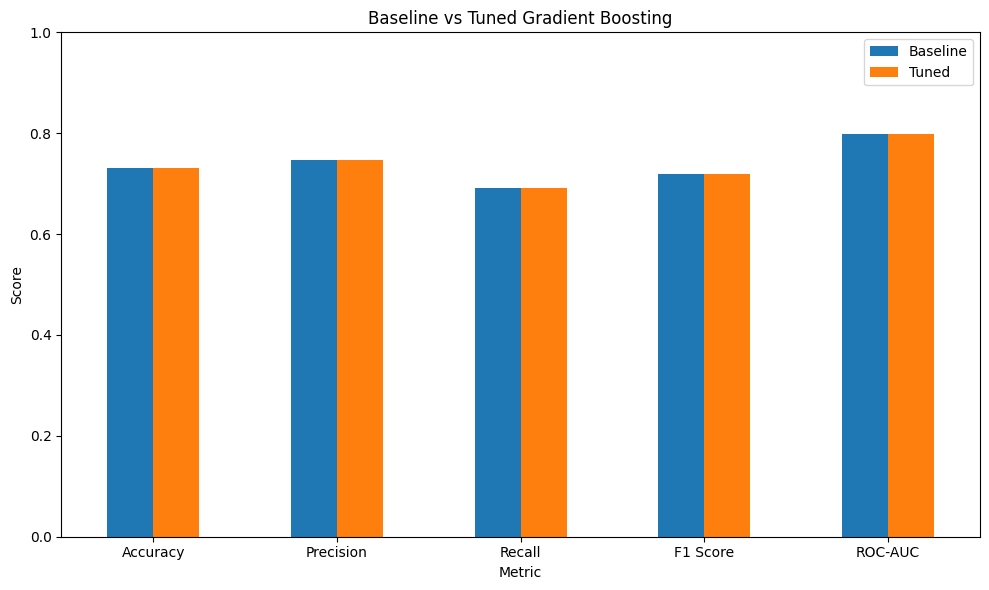

In [192]:
# ==========================================
# PERFORMANCE COMPARISON
# ==========================================

plot_comparison = comparison_gb.set_index(
    "Metric"
)[
    ["Baseline", "Tuned"]
]

plot_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Baseline vs Tuned Gradient Boosting"
)

plt.xlabel("Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()

plt.tight_layout()

plt.show()

In [193]:
# Optional: Tune Random Forest
# Since Random Forest had the highest recall among your baseline models, we can also tune it
# ==========================================
# RANDOM FOREST PARAMETERS
# ==========================================

rf_param_grid = {
    "n_estimators": [
        200,
        300,
        500
    ],

    "max_depth": [
        10,
        20,
        30,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2",
        None
    ]
}

In [194]:
# ==========================================
# RANDOM FOREST RANDOMIZED SEARCH
# ==========================================

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,

    param_distributions=rf_param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [195]:
# ==========================================
# FIT RANDOM FOREST SEARCH
# ==========================================

print("Starting Random Forest hyperparameter tuning...")

rf_random_search.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed!")

Starting Random Forest hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest tuning completed!


In [196]:
# ==========================================
# BEST RANDOM FOREST MODEL
# ==========================================

best_rf_model = rf_random_search.best_estimator_

print("Best Random Forest Parameters:")

print(
    rf_random_search.best_params_
)

print(
    "\nBest Cross-Validation ROC-AUC:",
    round(
        rf_random_search.best_score_,
        4
    )
)

Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}

Best Cross-Validation ROC-AUC: 0.7998


In [197]:
# ==========================================
# TUNED RANDOM FOREST PREDICTIONS
# ==========================================

tuned_rf_predictions = best_rf_model.predict(
    X_test
)

tuned_rf_probabilities = best_rf_model.predict_proba(
    X_test
)[:, 1]

In [198]:
# ==========================================
# TUNED RANDOM FOREST METRICS
# ==========================================

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_probabilities
)

print("Tuned Random Forest Results:\n")

print(f"Accuracy:  {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall:    {tuned_rf_recall:.4f}")
print(f"F1 Score:  {tuned_rf_f1:.4f}")
print(f"ROC-AUC:   {tuned_rf_auc:.4f}")

Tuned Random Forest Results:

Accuracy:  0.7293
Precision: 0.7604
Recall:    0.6652
F1 Score:  0.7096
ROC-AUC:   0.7977


In [199]:
# ==========================================
# TOP MODEL COMPARISON
# ==========================================

top_models_comparison = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        0.7303,
        tuned_gb_accuracy,
        tuned_rf_accuracy
    ],

    "Precision": [
        0.7475,
        tuned_gb_precision,
        tuned_rf_precision
    ],

    "Recall": [
        0.6911,
        tuned_gb_recall,
        tuned_rf_recall
    ],

    "F1 Score": [
        0.7182,
        tuned_gb_f1,
        tuned_rf_f1
    ],

    "ROC-AUC": [
        0.7978,
        tuned_gb_auc,
        tuned_rf_auc
    ]
})

top_models_comparison = top_models_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(
    top_models_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Tuned Gradient Boosting,0.7304,0.7471,0.6920,0.7185,0.7981
0,Baseline Gradient Boosting,0.7303,0.7475,0.6911,0.7182,0.7978
2,Tuned Random Forest,0.7293,0.7604,0.6652,0.7096,0.7977


**13. Final Model Evaluation** :
we will select the final model based on our tuning results and perform a detailed evaluation

In [200]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

display(top_models_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Tuned Gradient Boosting,0.7304,0.7471,0.6920,0.7185,0.7981
0,Baseline Gradient Boosting,0.7303,0.7475,0.6911,0.7182,0.7978
2,Tuned Random Forest,0.7293,0.7604,0.6652,0.7096,0.7977


In [201]:
# ==========================================
# SELECT FINAL MODEL
# ==========================================

best_model_name = top_models_comparison.loc[
    top_models_comparison["ROC-AUC"].idxmax(),
    "Model"
]

print("Selected Final Model:")
print(best_model_name)

Selected Final Model:
Tuned Gradient Boosting


In [202]:
# ==========================================
# ASSIGN FINAL MODEL
# ==========================================

if best_model_name == "Tuned Gradient Boosting":

    final_model = best_gb_model
    final_predictions = tuned_gb_predictions
    final_probabilities = tuned_gb_probabilities

elif best_model_name == "Tuned Random Forest":

    final_model = best_rf_model
    final_predictions = tuned_rf_predictions
    final_probabilities = tuned_rf_probabilities

else:

    # If baseline Gradient Boosting performs best
    final_model = gradient_boosting_model
    final_predictions = gradient_boosting_predictions
    final_probabilities = gradient_boosting_probabilities


print(f"Final model selected: {best_model_name}")

Final model selected: Tuned Gradient Boosting


In [203]:
# ==========================================
# FINAL MODEL METRICS
# ==========================================

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_auc = roc_auc_score(
    y_test,
    final_probabilities
)

print("FINAL MODEL PERFORMANCE")
print("=" * 40)

print(f"Model:     {best_model_name}")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1 Score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_auc:.4f}")

FINAL MODEL PERFORMANCE
Model:     Tuned Gradient Boosting
Accuracy:  0.7304
Precision: 0.7471
Recall:    0.6920
F1 Score:  0.7185
ROC-AUC:   0.7981


In [204]:
# ==========================================
# FINAL PERFORMANCE TABLE
# ==========================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

display(final_results.round(4))

,Metric,Score
0,Accuracy,0.7304
1,Precision,0.7471
2,Recall,0.6920
3,F1 Score,0.7185
4,ROC-AUC,0.7981


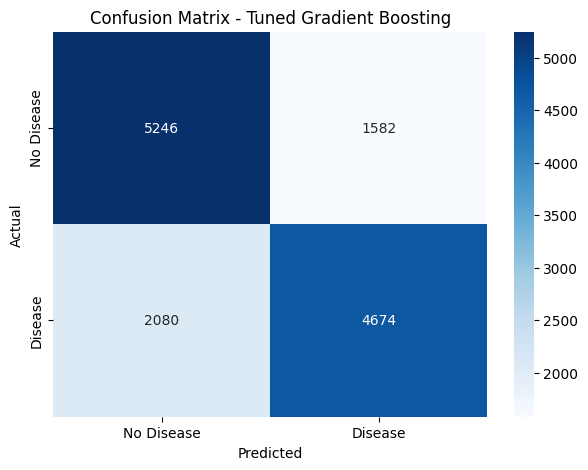

In [205]:
# ==========================================
# FINAL CONFUSION MATRIX
# ==========================================

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [206]:
# ==========================================
# CONFUSION MATRIX VALUES
# ==========================================

tn, fp, fn, tp = final_cm.ravel()

print("CONFUSION MATRIX RESULTS")
print("=" * 35)

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

CONFUSION MATRIX RESULTS
True Negatives:  5246
False Positives: 1582
False Negatives: 2080
True Positives:  4674


In [207]:
# ==========================================
# FINAL CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "No Disease",
            "Cardiovascular Disease"
        ]
    )
)

                        precision    recall  f1-score   support

            No Disease       0.72      0.77      0.74      6828
Cardiovascular Disease       0.75      0.69      0.72      6754

              accuracy                           0.73     13582
             macro avg       0.73      0.73      0.73     13582
          weighted avg       0.73      0.73      0.73     13582



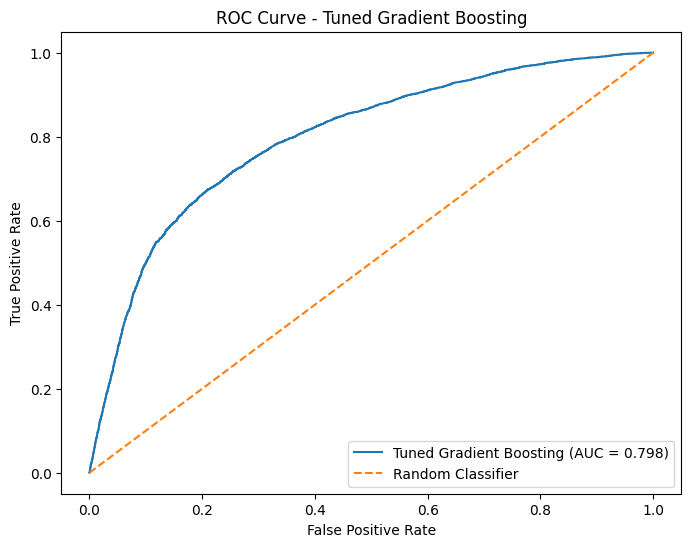

In [208]:
# ==========================================
# FINAL ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {final_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(
    loc="lower right"
)

plt.show()

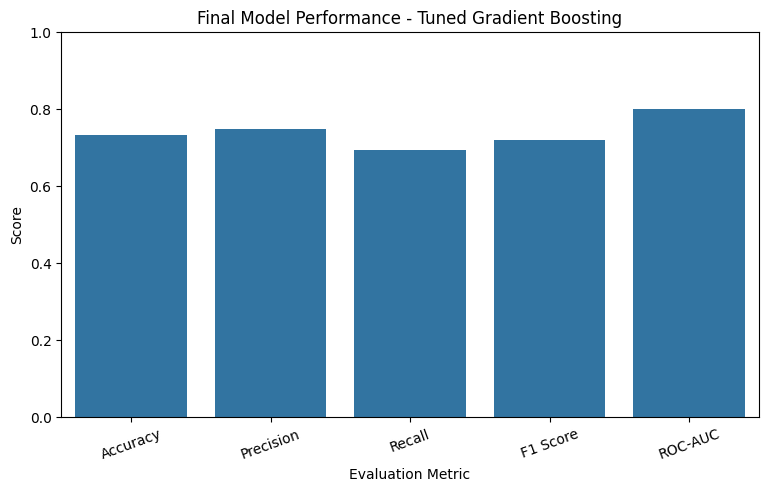

In [209]:
# ==========================================
# FINAL PERFORMANCE CHART
# ==========================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=final_results,
    x="Metric",
    y="Score"
)

plt.title(
    f"Final Model Performance - {best_model_name}"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

In [210]:
# ==========================================
# BASELINE VS FINAL MODEL
# ==========================================

baseline_metrics = [
    0.7303,
    0.7475,
    0.6911,
    0.7182,
    0.7978
]

final_metrics = [
    final_accuracy,
    final_precision,
    final_recall,
    final_f1,
    final_auc
]

comparison_final = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline Gradient Boosting": baseline_metrics,

    "Final Model": final_metrics
})

display(comparison_final.round(4))

,Metric,Baseline Gradient Boosting,Final Model
0,Accuracy,0.7303,0.7304
1,Precision,0.7475,0.7471
2,Recall,0.6911,0.6920
3,F1 Score,0.7182,0.7185
4,ROC-AUC,0.7978,0.7981


In [211]:
# ==========================================
# PERFORMANCE IMPROVEMENT
# ==========================================

comparison_final["Improvement"] = (
    comparison_final["Final Model"]
    - comparison_final["Baseline Gradient Boosting"]
)

display(comparison_final.round(4))

,Metric,Baseline Gradient Boosting,Final Model,Improvement
0,Accuracy,0.7303,0.7304,0.0001
1,Precision,0.7475,0.7471,-0.0004
2,Recall,0.6911,0.6920,0.0009
3,F1 Score,0.7182,0.7185,0.0003
4,ROC-AUC,0.7978,0.7981,0.0003


In [212]:
# ==========================================
# FINAL MODEL SUMMARY
# ==========================================

print("=" * 50)
print("CARDIOVASCULAR DISEASE PREDICTION")
print("FINAL MACHINE LEARNING MODEL")
print("=" * 50)

print(f"\nSelected Model: {best_model_name}")

print("\nPerformance Metrics:")
print(f"Accuracy:  {final_accuracy:.2%}")
print(f"Precision: {final_precision:.2%}")
print(f"Recall:    {final_recall:.2%}")
print(f"F1 Score:  {final_f1:.2%}")
print(f"ROC-AUC:   {final_auc:.2%}")

print("\nBaseline Gradient Boosting Accuracy: 73.03%")

print("=" * 50)

CARDIOVASCULAR DISEASE PREDICTION
FINAL MACHINE LEARNING MODEL

Selected Model: Tuned Gradient Boosting

Performance Metrics:
Accuracy:  73.04%
Precision: 74.71%
Recall:    69.20%
F1 Score:  71.85%
ROC-AUC:   79.81%

Baseline Gradient Boosting Accuracy: 73.03%


**14. Feature Importance & Model Interpretability**

Which features contributed most to the cardiovascular disease predictions?

In [213]:
# ==========================================
# CHECK FINAL MODEL
# ==========================================

print("Final Model:")
print(best_model_name)

print("\nModel Details:")
print(final_model)

Final Model:
Tuned Gradient Boosting

Model Details:
GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=4,
                           min_samples_split=5, n_estimators=200,
                           random_state=42, subsample=0.9)


In [214]:
feature_columns

['age_years',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'bmi',
 'bp_difference',
 'bp_ratio']

In [215]:
# ==========================================
# EXTRACT FEATURE IMPORTANCE
# ==========================================

feature_importance = final_model.feature_importances_

print("Feature importance extracted successfully!")

Feature importance extracted successfully!


In [216]:
# ==========================================
# FEATURE IMPORTANCE DATAFRAME
# ==========================================

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
4,ap_hi,0.733178
0,age_years,0.126724
6,cholesterol,0.079252
11,bmi,0.016721
5,ap_lo,0.012954
3,weight,0.008896
10,active,0.005788
7,gluc,0.005019
8,smoke,0.002747
13,bp_ratio,0.002648


In [217]:
# ==========================================
# FEATURE IMPORTANCE PERCENTAGE
# ==========================================

importance_percentage = importance_df.copy()

importance_percentage["Importance (%)"] = (
    importance_percentage["Importance"] * 100
).round(2)

display(
    importance_percentage[
        ["Feature", "Importance (%)"]
    ]
)

,Feature,Importance (%)
4,ap_hi,73.32
0,age_years,12.67
6,cholesterol,7.93
11,bmi,1.67
5,ap_lo,1.30
3,weight,0.89
10,active,0.58
7,gluc,0.50
8,smoke,0.27
13,bp_ratio,0.26


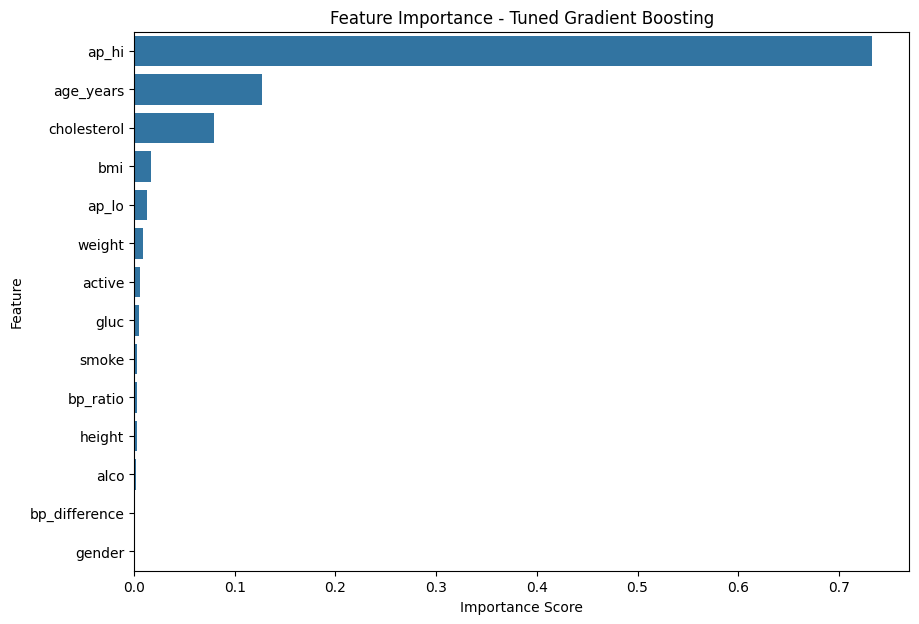

In [218]:
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    f"Feature Importance - {best_model_name}"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [219]:
# ==========================================
# TOP 5 FEATURES
# ==========================================

top_5_features = importance_df.head(5)

print("Top 5 Most Important Features:")
print("=" * 40)

for index, row in top_5_features.iterrows():

    print(
        f"{row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

Top 5 Most Important Features:
ap_hi: 0.7332
age_years: 0.1267
cholesterol: 0.0793
bmi: 0.0167
ap_lo: 0.0130


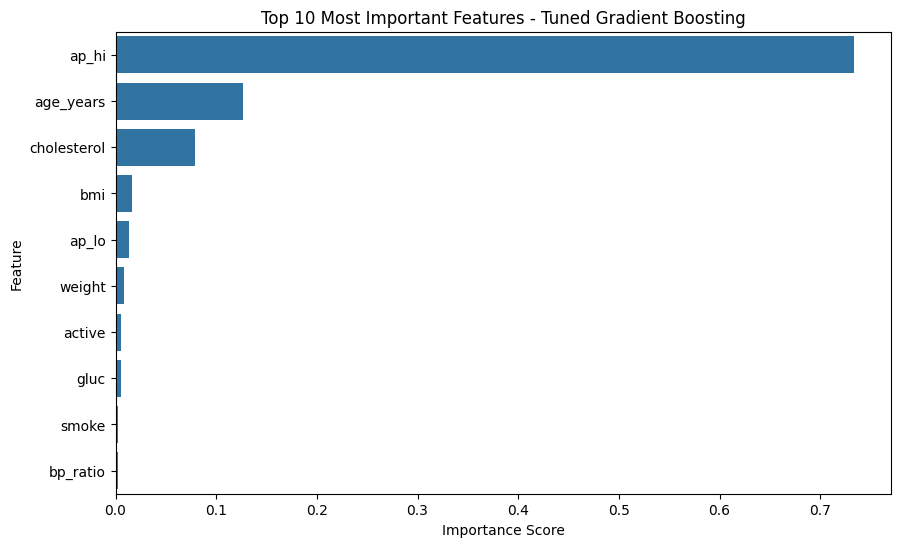

In [220]:
# ==========================================
# TOP 10 FEATURES
# ==========================================

top_10_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature"
)

plt.title(
    f"Top 10 Most Important Features - {best_model_name}"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [221]:
# ==========================================
# CUMULATIVE FEATURE IMPORTANCE
# ==========================================

importance_df["Cumulative Importance"] = (
    importance_df["Importance"].cumsum()
)

display(
    importance_df[
        [
            "Feature",
            "Importance",
            "Cumulative Importance"
        ]
    ].round(4)
)

,Feature,Importance,Cumulative Importance
4,ap_hi,0.7332,0.7332
0,age_years,0.1267,0.8599
6,cholesterol,0.0793,0.9392
11,bmi,0.0167,0.9559
5,ap_lo,0.0130,0.9688
3,weight,0.0089,0.9777
10,active,0.0058,0.9835
7,gluc,0.0050,0.9885
8,smoke,0.0027,0.9913
13,bp_ratio,0.0026,0.9939


In [222]:
# ==========================================
# FEATURES EXPLAINING 80%
# ==========================================

features_80_percent = importance_df[
    importance_df["Cumulative Importance"] <= 0.80
]

print(
    "Number of features contributing "
    "approximately 80% of importance:"
)

print(
    len(features_80_percent)
)

print("\nFeatures:")

print(
    features_80_percent["Feature"].tolist()
)

Number of features contributing approximately 80% of importance:
1

Features:
['ap_hi']


In [223]:
# ==========================================
# FEATURE IMPORTANCE SUMMARY
# ==========================================

print("=" * 55)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 55)

print(f"\nFinal Model: {best_model_name}")

print("\nTop 5 Most Important Features:")

for rank, (_, row) in enumerate(
    importance_df.head(5).iterrows(),
    start=1
):

    print(
        f"{rank}. {row['Feature']} "
        f"({row['Importance']:.4f})"
    )

print("=" * 55)

FEATURE IMPORTANCE SUMMARY

Final Model: Tuned Gradient Boosting

Top 5 Most Important Features:
1. ap_hi (0.7332)
2. age_years (0.1267)
3. cholesterol (0.0793)
4. bmi (0.0167)
5. ap_lo (0.0130)


In [224]:
# ==========================================
# SAVE FEATURE IMPORTANCE
# ==========================================

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


**15. Save the Final Model**

In [226]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

import joblib
joblib.dump(
    final_model,
    "cardiovascular_disease_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [227]:
# ==========================================
# SAVE SCALER
# ==========================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [228]:
# ==========================================
# SAVE FEATURE COLUMNS
# ==========================================

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [229]:
# ==========================================
# VERIFY SAVED FILES
# ==========================================

import os

files_to_check = [
    "cardiovascular_disease_model.pkl",
    "scaler.pkl",
    "feature_columns.pkl"
]

for file in files_to_check:

    if os.path.exists(file):
        print(f"✓ {file} saved successfully")
    else:
        print(f"✗ {file} not found")

✓ cardiovascular_disease_model.pkl saved successfully
✓ scaler.pkl saved successfully
✓ feature_columns.pkl saved successfully


In [230]:
# ==========================================
# LOAD SAVED FILES
# ==========================================

loaded_model = joblib.load(
    "cardiovascular_disease_model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

loaded_feature_columns = joblib.load(
    "feature_columns.pkl"
)

print("All saved files loaded successfully!")

All saved files loaded successfully!


In [231]:
# ==========================================
# CHECK FEATURE COLUMNS
# ==========================================

print("Number of features:", len(loaded_feature_columns))

print("\nFeature columns:")

for feature in loaded_feature_columns:
    print("-", feature)

Number of features: 14

Feature columns:
- age_years
- gender
- height
- weight
- ap_hi
- ap_lo
- cholesterol
- gluc
- smoke
- alco
- active
- bmi
- bp_difference
- bp_ratio


In [232]:
# ==========================================
# TEST LOADED MODEL
# ==========================================

sample_data = X_test.iloc[:5]

loaded_predictions = loaded_model.predict(
    sample_data
)

print("Sample Predictions:")
print(loaded_predictions)

Sample Predictions:
[1 1 1 0 0]


In [233]:
# ==========================================
# VERIFY LOADED MODEL
# ==========================================

loaded_test_predictions = loaded_model.predict(
    X_test
)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_test_predictions
)

print(
    f"Loaded Model Accuracy: {loaded_accuracy:.4f}"
)

print(
    f"Original Final Model Accuracy: {final_accuracy:.4f}"
)

Loaded Model Accuracy: 0.7304
Original Final Model Accuracy: 0.7304


In [234]:
# ==========================================
# CREATE MODEL FOLDER
# ==========================================

os.makedirs(
    "models",
    exist_ok=True
)

print("Models folder created!")

Models folder created!


In [235]:
# ==========================================
# SAVE ALL ARTIFACTS IN MODELS FOLDER
# ==========================================

joblib.dump(
    final_model,
    "models/cardiovascular_disease_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)

print("All model files saved inside models folder!")

All model files saved inside models folder!


**16. Create a Prediction Function**

In [242]:
# ==========================================
# CHECK FEATURE COLUMNS
# ==========================================

print(feature_columns)

['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_difference', 'bp_ratio']


In [243]:
# Check the exact features used by the model

print("Features expected by the model:")
print(feature_columns)

print("\nNumber of features:", len(feature_columns))

Features expected by the model:
['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'bp_difference', 'bp_ratio']

Number of features: 14


In [244]:
# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_cardiovascular_disease(
    age_years,
    gender,
    height,
    weight,
    ap_hi,
    ap_lo,
    cholesterol,
    gluc,
    smoke,
    alco,
    active
):

    # ==========================================
    # FEATURE ENGINEERING
    # ==========================================

    # Calculate BMI
    bmi = weight / ((height / 100) ** 2)

    # Calculate blood pressure difference
    bp_difference = ap_hi - ap_lo

    # Calculate blood pressure ratio
    bp_ratio = ap_hi / ap_lo


    # ==========================================
    # CREATE INPUT DICTIONARY
    # ==========================================

    input_dict = {
        "age_years": age_years,
        "gender": gender,
        "height": height,
        "weight": weight,
        "ap_hi": ap_hi,
        "ap_lo": ap_lo,
        "cholesterol": cholesterol,
        "gluc": gluc,
        "smoke": smoke,
        "alco": alco,
        "active": active,
        "bmi": bmi,
        "bp_difference": bp_difference,
        "bp_ratio": bp_ratio
    }


    # ==========================================
    # CREATE DATAFRAME
    # ==========================================

    input_df = pd.DataFrame(
        [input_dict]
    )


    # ==========================================
    # ENSURE CORRECT FEATURE ORDER
    # ==========================================

    input_df = input_df[feature_columns]


    # ==========================================
    # MAKE PREDICTION
    # ==========================================

    prediction = final_model.predict(
        input_df
    )[0]


    # ==========================================
    # GET PROBABILITY
    # ==========================================

    probability = final_model.predict_proba(
        input_df
    )[0][1]


    # ==========================================
    # CONVERT PREDICTION TO LABEL
    # ==========================================

    if prediction == 1:
        result = "Cardiovascular Disease"
    else:
        result = "No Cardiovascular Disease"


    return result, probability

In [247]:
# ==========================================
# TEST PREDICTION FUNCTION
# ==========================================

result, probability = predict_cardiovascular_disease(
    age_years=55,
    gender=1,
    height=170,
    weight=85,
    ap_hi=140,
    ap_lo=90,
    cholesterol=2,
    gluc=1,
    smoke=0,
    alco=0,
    active=1
)

print("Prediction:", result)

print(
    f"Probability of Cardiovascular Disease: "
    f"{probability:.2%}"
)

Prediction: Cardiovascular Disease
Probability of Cardiovascular Disease: 83.47%


In [248]:
#final model checking
print(type(final_model))
print(final_model)

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=4,
                           min_samples_split=5, n_estimators=200,
                           random_state=42, subsample=0.9)


In [249]:
import sklearn
import joblib

print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Scikit-learn: 1.6.1
Joblib: 1.5.3
